# Проектная работа
# "*Основы машинного обучения*"

### Описание проекта

**Заказчик исследования**: Сеть фитнес-центров «Культурист-датасаентист».

**Цель исследования**:
Провести анализ и подготовить план действий по удержанию клиентов сети фитнес-центров «Культурист-датасаентист», а именно:
- спрогнозировать вероятность оттока (на уровне следующего месяца) для каждого клиента;
- сформировать типичные портреты клиентов: выделить несколько наиболее ярких групп и охарактеризовать их основные свойства;
- проанализировать основные признаки, наиболее сильно влияющие на отток;
- сформулировать основные выводы и разработать рекомендации по повышению качества работы с клиентами:
    - выделить целевые группы клиентов;
    - предложить меры по снижению оттока;
    - определить другие особенности взаимодействия с клиентами.

**Ход исследования**:

Данные для предстоящего анализа получим из файла:
- `/datasets/gym_churn.csv`.

О качестве данных ничего не известно. Поэтому перед анализом понадобится их обзор с целью выявления ошибок и оценки их влияния на предстоящее исследование. 

В предобработке будет проведена работа по исправлению найденных ошибок. 

Далее проведем исследовательский анализ данных, направленный на просмотр средних значений признаков в двух группах (отток/остался), построение столбчатых гистограмм и распределения признаков для тех кто ушел и кто остался, построение матрицы корреляции. 

Затем построим модель прогнозирования оттока клиентов, осуществим кластеризацию клиентов. 

На основании полученных данных сделаем выводы и сформулируем краткие рекомендации.

**Описание данных**

«Культурист-датасаентист» предоставил сведения в csv-файлах. Заказчик подготовил данные, которые содержат данные на месяц до оттока и факт оттока на определённый месяц. Набор данных включает следующие поля:
1. **Данные клиента за предыдущий до проверки факта оттока месяц**:
- `gender` — пол;
- `Near_Location` — проживание или работа в районе, где находится фитнес-центр;
- `Partner` — сотрудник компании-партнёра клуба (сотрудничество с компаниями, чьи сотрудники могут получать скидки на абонемент — в таком случае фитнес-центр хранит информацию о работодателе клиента);
- `Promo_friends` — факт первоначальной записи в рамках акции «приведи друга» (использовал промо-код от знакомого при оплате первого абонемента);
- `Phone` — наличие контактного телефона;
- `Age` — возраст;
- `Lifetime` — время с момента первого обращения в фитнес-центр (в месяцах).
2. **Информация на основе журнала посещений, покупок и информация о текущем статусе абонемента клиента**:
- `Contract_period` — длительность текущего действующего абонемента (месяц, 6 месяцев, год);
- `Month_to_end_contract` — срок до окончания текущего действующего абонемента (в месяцах);
- `Group_visits` — факт посещения групповых занятий;
- `Avg_class_frequency_total` — средняя частота посещений в неделю за все время с начала действия абонемента;
- `Avg_class_frequency_current_month` — средняя частота посещений в неделю за предыдущий месяц;
- `Avg_additional_charges_total` — суммарная выручка от других услуг фитнес-центра: кафе, спорттовары, косметический и массажный салон.
3. `Churn` — факт оттока в текущем месяце.

Таким образом, **исследование пройдёт в пять этапов**:

1. [Загрузка данных](#data)
2. [Исследовательский анализ данных(EDA)](#data_analysis)
3. [Построение модели прогнозирования оттока клиентов](#churn_prediction_model)
4. [Кластеризация клиентов](#client_clusteringn)
5. [Формирование выводов и рекомендаций](#conclusions_recommendations)

### Загрузка данных

Импортируем основные библиотеки, которые понадобятся нам в дальнейшем. Считаем данные из csv-файла в датафрейм и сохраним в переменную `gym_churn`.
<a id='data'></a>
Путь к файлу:   

`/datasets/gym_churn.csv`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import KMeans
import itertools
import plotly.express as px

Сразу настроим ширину отображения ячеек Jupyter Notebook, чтобы рабочая область выглядела шире и удобнее для чтения:

In [2]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

Так же, в начале проекта, **установим единственный источник случайности `RANDOM_STATE`, равный `42`.** Он будет одинаковым на всех этапах настоящей работы. Это обеспечит детерминированность результатов на всех этапах, включая разделение данных и обучение моделей.

***Примечание:*** *выбор значения `42` как `random_state` стал своеобразным мемом в сообществе разработчиков и аналитиков благодаря культовому произведению "Автостопом по галактике" (The Hitchhiker's Guide to the Galaxy) Дугласа Адамса. В книге число 42 упоминается как "Ответ на главный вопрос жизни, Вселенной и всего такого". Число 42 часто используется как стандартное значение random_state в учебных материалах, книгах и онлайн-курсах. Это помогает поддерживать консистентность и узнаваемость кода. Можно выбрать любое другое число, но 42 стал популярным выбором из-за культурной отсылки. Поэтому в проекте тоже будем использовать именно это значение единственного источника случайности.*

In [3]:
# Фиксируем random_state
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [4]:
try:
    gym_churn  = (
        pd.read_csv('/datasets/gym_churn.csv')
    )
except:
    gym_churn = (
        pd.read_csv('C:/Users/Мария/Desktop/Практикум/Датасеты/Машинное обучение_Проект/gym_churn.csv') 
    )  

gym_churn.head()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


Данные загружены, переходим к исследовательскому анализу данных.

###  Исследовательский анализ данных (EDA)
#### Первичный обзор и предобработка данных
<a id='data_analysis'></a>


Изучим данные и выполним предобработку, если это будет необходимо. Проверим, есть ли в данных пропуски и дубликаты. Убедимся, что типы данных во всех колонках соответствуют сохранённым в них значениям. Изучим средние значения и стандартные отклонения.

Для начала проведем первичный анализ имеющегося датафрейма. Воспользуемся функцией `analyze_all_dfs`

In [5]:
def analyze_all_dfs(gym_churn):
    # Внутри функции создаем словарь dfs, где каждому датафрейму даем имя 
    dfs = {
        "gym_churn (данные о клиентах сети фитнес-центров «Культурист-датасаентист»)": gym_churn
          }
    
    # Функция последовательно проходит по каждому датафрейму и выводит результаты анализа по стандартному набору операций:  
    for name, df in dfs.items():
        print(f"\n=== Первичный анализ датафрейма {name} ===")

        print("\n1. Общая информация:")
        print('*'*40)
        df.info()

        print("\n2. Анализ пропусков в данных:")
        print('*'*40)
        print(df.isna().sum())

        print("\n3. Вывод первых 5 строк:")
        print('*'*40)
        display(df.head())

        print("\n4. Статистика по числовым столбцам:")
        print('*'*40)
        display(df.describe())

        print("\n5. Проверка на дубликаты:")
        print('*'*40)
        print(f"Количество дубликатов: {df.duplicated().sum()}")

        print("\n" + "="*50 + "\n")

analyze_all_dfs(gym_churn)


=== Первичный анализ датафрейма gym_churn (данные о клиентах сети фитнес-центров «Культурист-датасаентист») ===

1. Общая информация:
****************************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0



4. Статистика по числовым столбцам:
****************************************


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000



5. Проверка на дубликаты:
****************************************
Количество дубликатов: 0




Из полученной информации по анализируемому датафрейму `gym_churn` можно сделать следующий вывод:
- содержит `4000 строк` и `14 столбцов`;
- наименование столбцов `не` соответствуют стилю `snake_case` - нужно сделать все названия столбцов строчными буквами;
- все указанные типы данных соответствуют данным, содержащимся в столбцах;
- пропусков нет;
- дубликатов нет.

Изучив **средние значения и стандартные отклонения** с применением метода `describe()`, можно сказать, что:

1. *Пол (`gender`)*:
   - Среднее значение ~0.51, что близко к равному распределению между мужчинами и женщинами.
   - Стандартное отклонение ~0.5, что указывает на сбалансированное распределение.
----
2. *Проживание рядом (`Near_Location`)*:
   - Среднее значение ~0.85, большинство клиентов проживают или работают рядом с фитнес-центром.
   - Низкое стандартное отклонение (~0.36) подтверждает однородность по этому признаку.
----
3. *Сотрудничество с партнёром (`Partner`)*:
   - Среднее значение ~0.49, почти половина клиентов связаны с компаниями-партнёрами.
   - Стандартное отклонение ~0.5, что также говорит о равномерном распределении.
----
4. *Приведи друга (`Promo_friends`)*:
   - Среднее значение ~0.31, небольшой процент клиентов привёл друзей по акции.
   - Стандартное отклонение ~0.46, что отражает значительную вариативность.
----
5. *Контактный телефон (`Phone`)*:
   - Среднее значение ~0.9, большинство клиентов указали телефон.
   - Низкое стандартное отклонение (~0.3) указывает на однородность.
----
6. *Срок абонемента (`Contract_period`)*:
   - Среднее значение ~4.68 месяца, что свидетельствует о популярности краткосрочных контрактов.
   - Высокое стандартное отклонение (~4.55) указывает на значительную вариативность.
----
7. *Групповые занятия (`Group_visits`)*:
   - Среднее значение ~0.41, что означает, что групповые занятия посещает менее половины клиентов.
   - Стандартное отклонение ~0.49, указывающее на чёткое разделение между участниками и неучастниками.
----
8. *Возраст (`Age`)*:
   - Средний возраст ~29 лет.
   - Стандартное отклонение ~3.26, что говорит о небольшой вариативности.
----
9. *Суммарная выручка от дополнительных услуг (`Avg_additional_charges_total`)*:
   - Среднее значение ~146.94.
   - Высокое стандартное отклонение ~96.36 указывает на разброс в использовании дополнительных услуг.
----
10. *Срок до окончания абонемента (`Month_to_end_contract`)*:
    - Среднее значение ~4.32 месяца.
    - Высокое стандартное отклонение ~4.19, что указывает на широкий диапазон оставшегося времени.
----
11. *Средняя частота посещений за всё время (`Avg_class_frequency_total`)*:
    - Среднее значение ~1.88 раз в неделю.
    - Стандартное отклонение ~0.97, что указывает на умеренную вариативность.
----
12. *Средняя частота посещений за последний месяц (`Avg_class_frequency_current_month`)*:
    - Среднее значение ~1.77 раз в неделю, что немного ниже частоты за всё время.
    - Стандартное отклонение ~1.05, что также указывает на умеренную вариативность.
----
13. *Отток (`Churn`)*:
    - Среднее значение ~0.27, что означает, что около 27% клиентов находятся в группе оттока.
    - Стандартное отклонение ~0.44, что указывает на чёткое разделение между ушедшими и оставшимися клиентами.
----
Таким образом, *большинство клиентов проживают или работают рядом с фитнес-центром, указывают контактный телефон и имеют краткосрочные контракты.* 

*В оттоке находится значительная доля клиентов (27%), что требует внимания.*

*Разброс по дополнительным расходам и оставшемуся времени контракта значителен, что может быть важным фактором для анализа.*

Прежде, чем переходить к следующему этапу EDA, **преобразуем названия всех столбцов датасета `gym_churn` в строчные буквы**:

In [6]:
# Преобразуем названия столбцов в строчные буквы
gym_churn.columns = gym_churn.columns.str.lower()

# Проверка
gym_churn.head()

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


Все отлично, теперь наименование столбцов соответствуют стилю `snake_case`. Переходим к просмотру средних значений признаков в двух группах (отток/остался).

#### Просмотр средних значений признаков в двух группах (отток/остался)

Посмотрим на средние значения признаков в двух группах — тех, кто ушел в отток и тех, кто остался (воспользуемся методом `groupby()`):

In [7]:
# Просмотр средних значений признаков в двух группах (отток/остался)
def analyze_groups(data, target_column):
    print("\n=== Средние значения признаков в группах ===")
    group_means = data.groupby(target_column).mean()
    display(group_means)
    return group_means
group_means = analyze_groups(gym_churn, target_column='churn')


=== Средние значения признаков в группах ===


,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month
churn,,,,,,,,,,,,,
0,0.510037,0.873086,0.534195,0.353522,0.903709,5.747193,0.464103,29.976523,158.445715,5.283089,4.711807,2.024876,2.027882
1,0.510839,0.768143,0.355325,0.183789,0.902922,1.728558,0.268615,26.989632,115.082899,1.662582,0.990575,1.474995,1.044546


На основании средних значений признаков в двух группах (`churn = 0` — остались, `churn = 1` — ушли в отток) можно сделать следующие наблюдения:

-  **near location**: У клиентов, которые остались, показатель близости к местоположению фитнес-центра выше (0.87 против 0.77). Это указывает на то, что проживание или работа рядом с клубом влияет на вероятность удержания клиента.

-  **partner**: У клиентов, оставшихся в клубе, чаще отмечен факт работы в компании-партнёре (0.53 против 0.36). Сотрудничество с компаниями может быть эффективной стратегией удержания.

-  **promo friends**: У клиентов, оставшихся, чаще встречается использование промо-акции «Приведи друга» при записи (0.35 против 0.18). Это может быть хорошим стимулом для привлечения более лояльных клиентов.

- **contract period**: У клиентов, оставшихся, средняя продолжительность абонемента значительно выше (5.75 месяца против 1.73 месяца). Длительные контракты положительно влияют на удержание.

-  **age**: У клиентов, которые остались, средний возраст выше (30 лет против 27 лет). Это может указывать на то, что возрастные клиенты более склонны к длительным посещениям.

-  **average additional charges**: У оставшихся клиентов выше средняя выручка от дополнительных услуг (158.45 против 115.08). Это показывает, что лояльные клиенты склонны больше тратить на дополнительные предложения.

-  **lifetime**: Клиенты, оставшиеся, имеют большее время с момента первой записи (4.71 года против 0.99 года). Это логично, так как более новые клиенты чаще попадают в отток.

-  **average class frequency**: У оставшихся клиентов выше частота посещений как за всё время (2.02 против 1.47), так и за последний месяц (2.03 против 1.04). Регулярность занятий играет ключевую роль в удержании.

**Вывод**: Основные отличия между группами можно связать с близостью к клубу, длительностью абонемента, возрастом, активностью (посещаемостью) и использованием промо-акций. Эти показатели можно использовать для таргетинга и стратегий удержания клиентов.

#### Построение столбчатых гистограмм и распределения признаков для тех, кто ушёл (отток) и тех, кто остался (не попали в отток)

Построим столбчатые гистограммы и распределения признаков для тех, кто ушёл (отток) и тех, кто остался (не попали в отток). Сначала создадим словарь с расшифровкой бинарных признаков для упрощения интерпретации графиков. Затем с помощью функции `graph_plotting_function` построим графики.

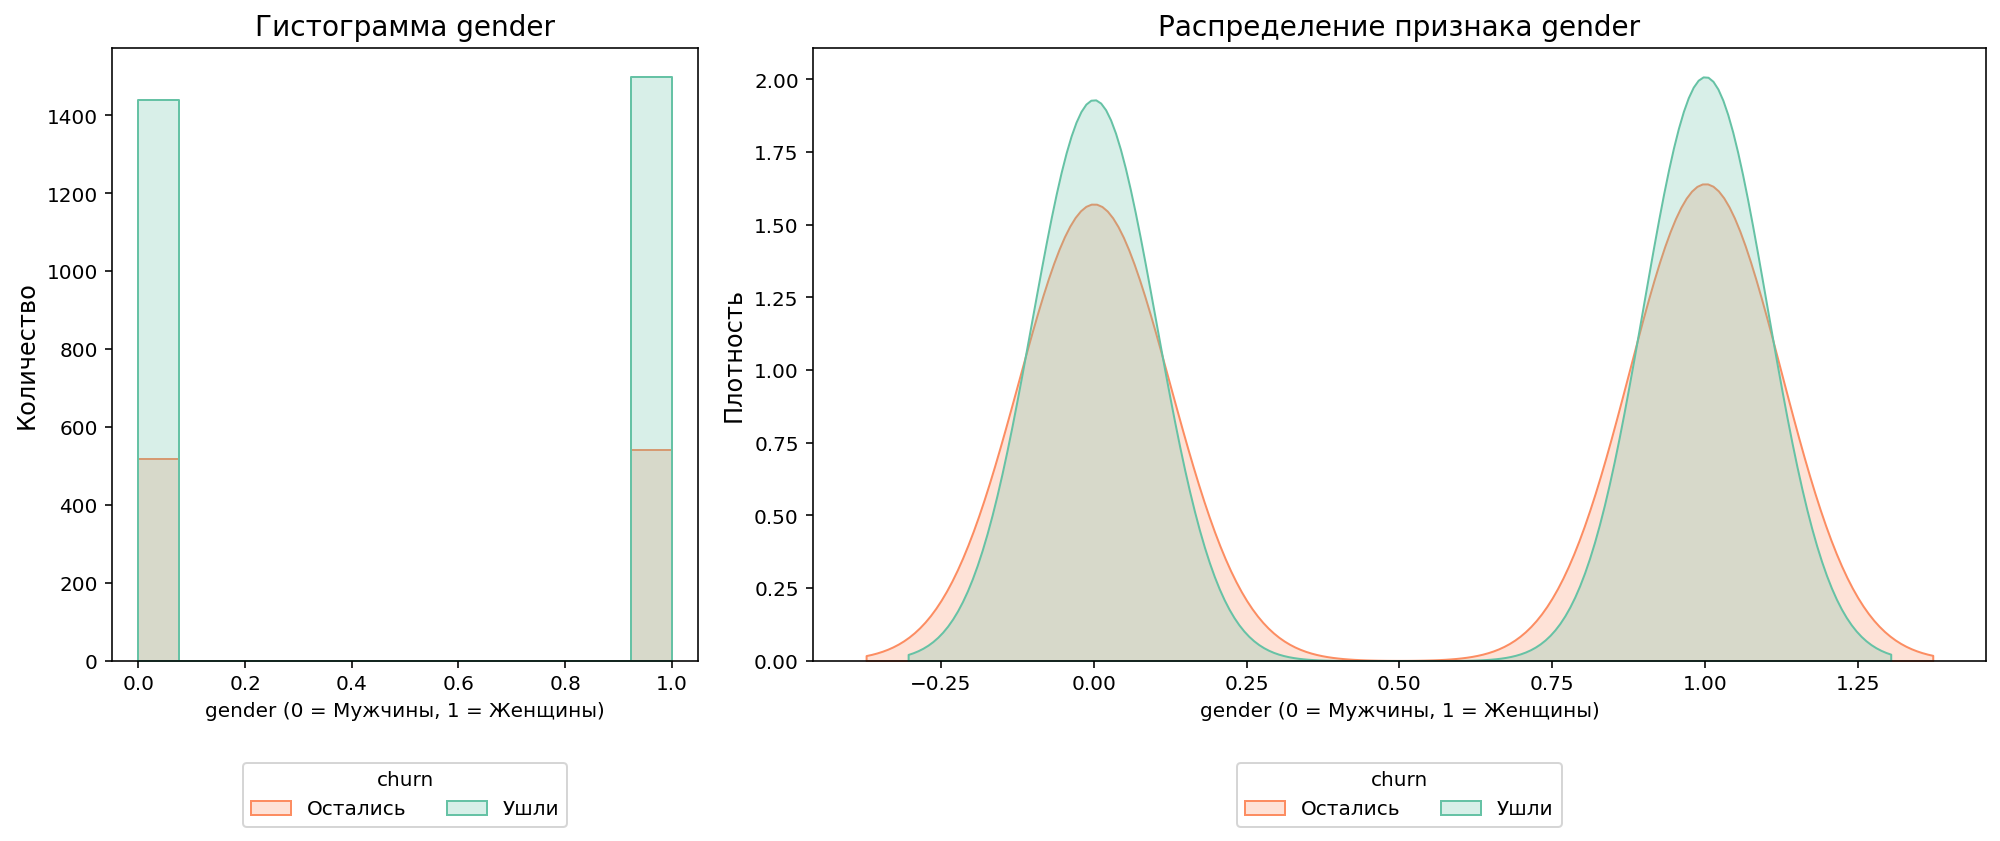

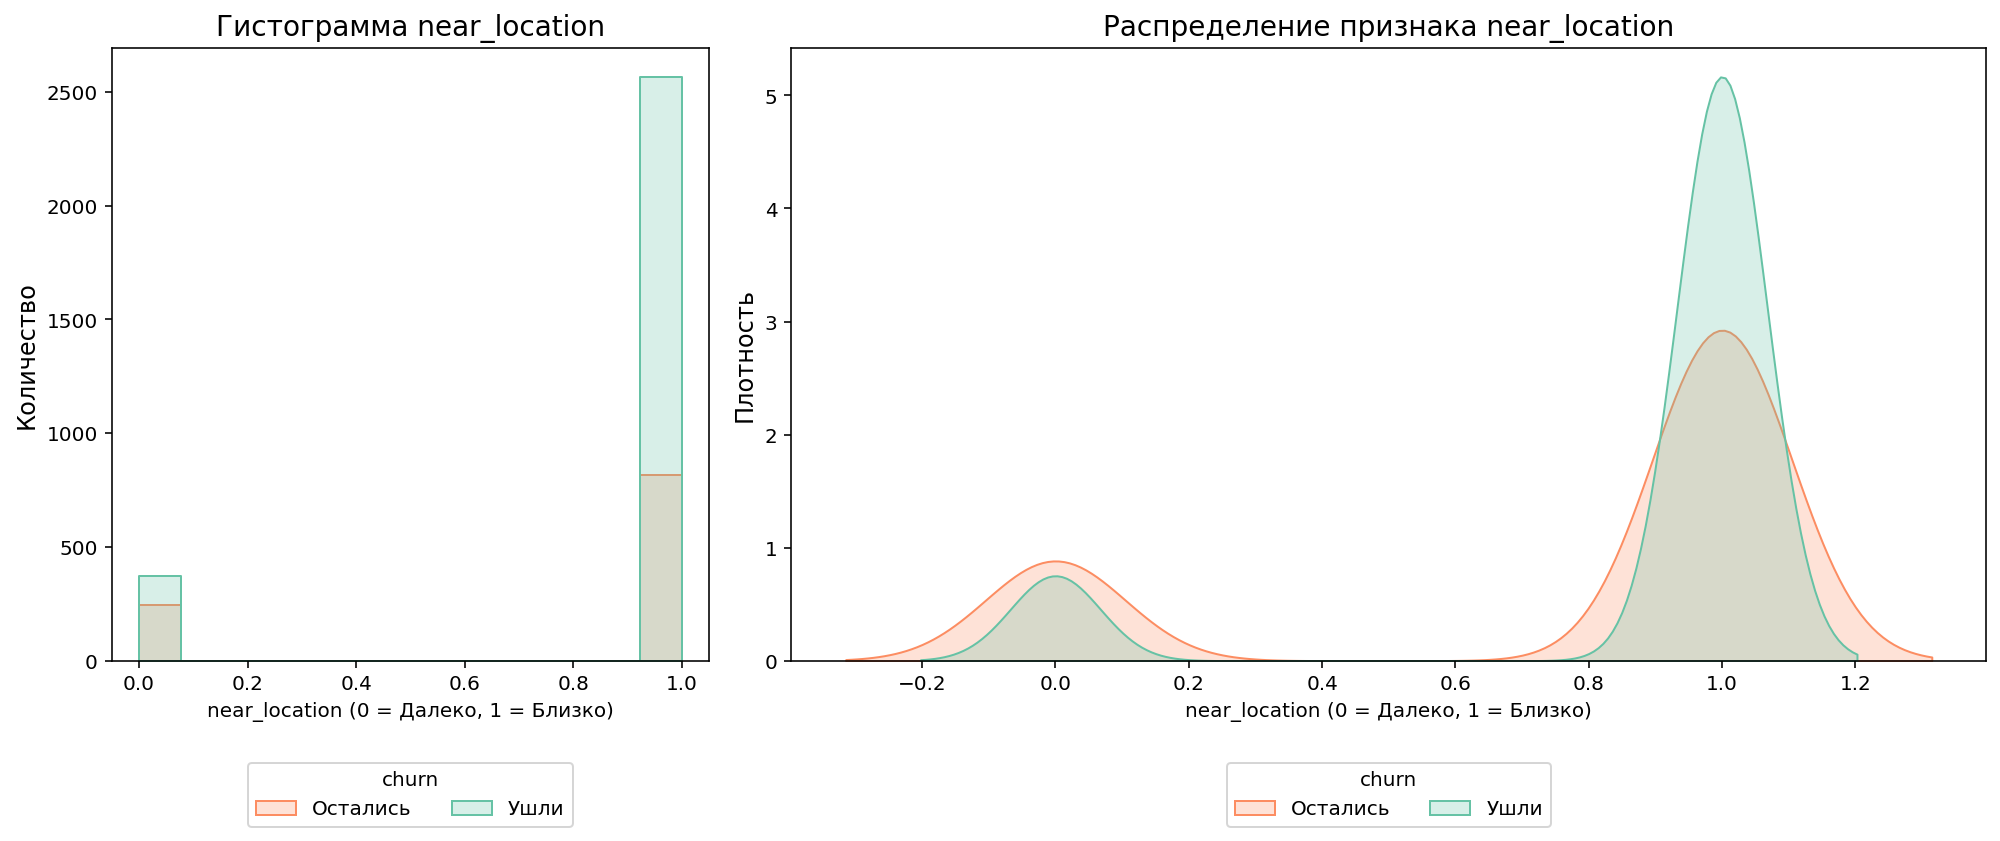

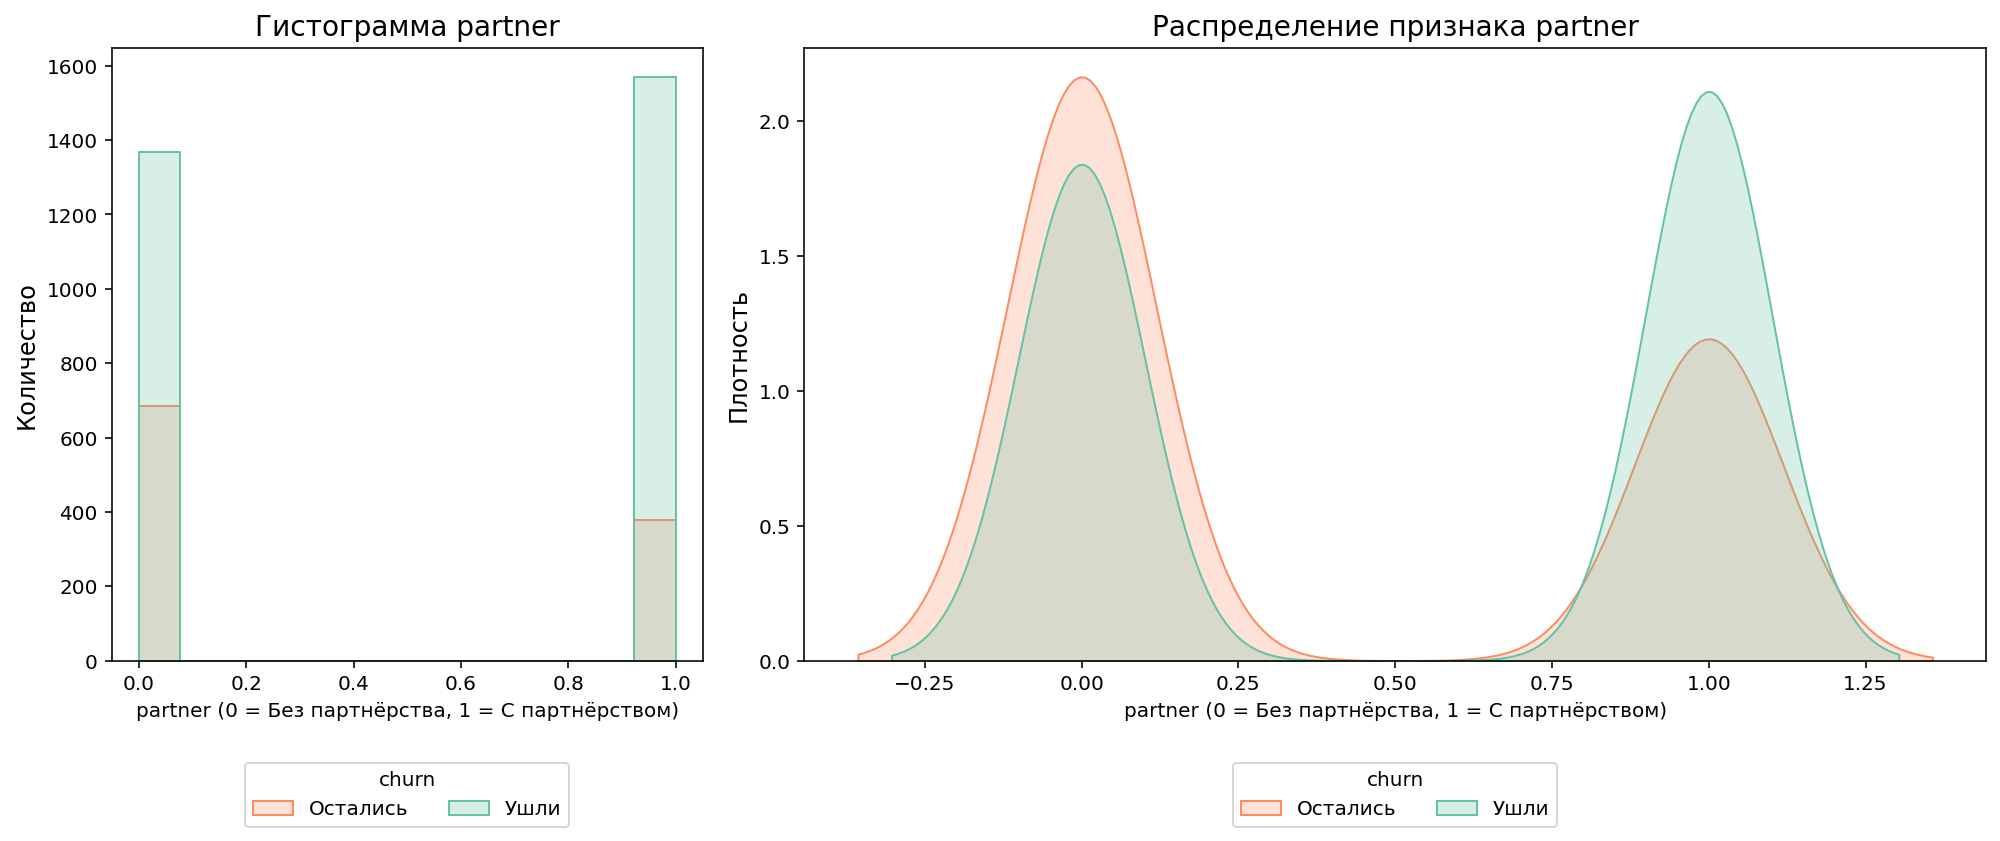

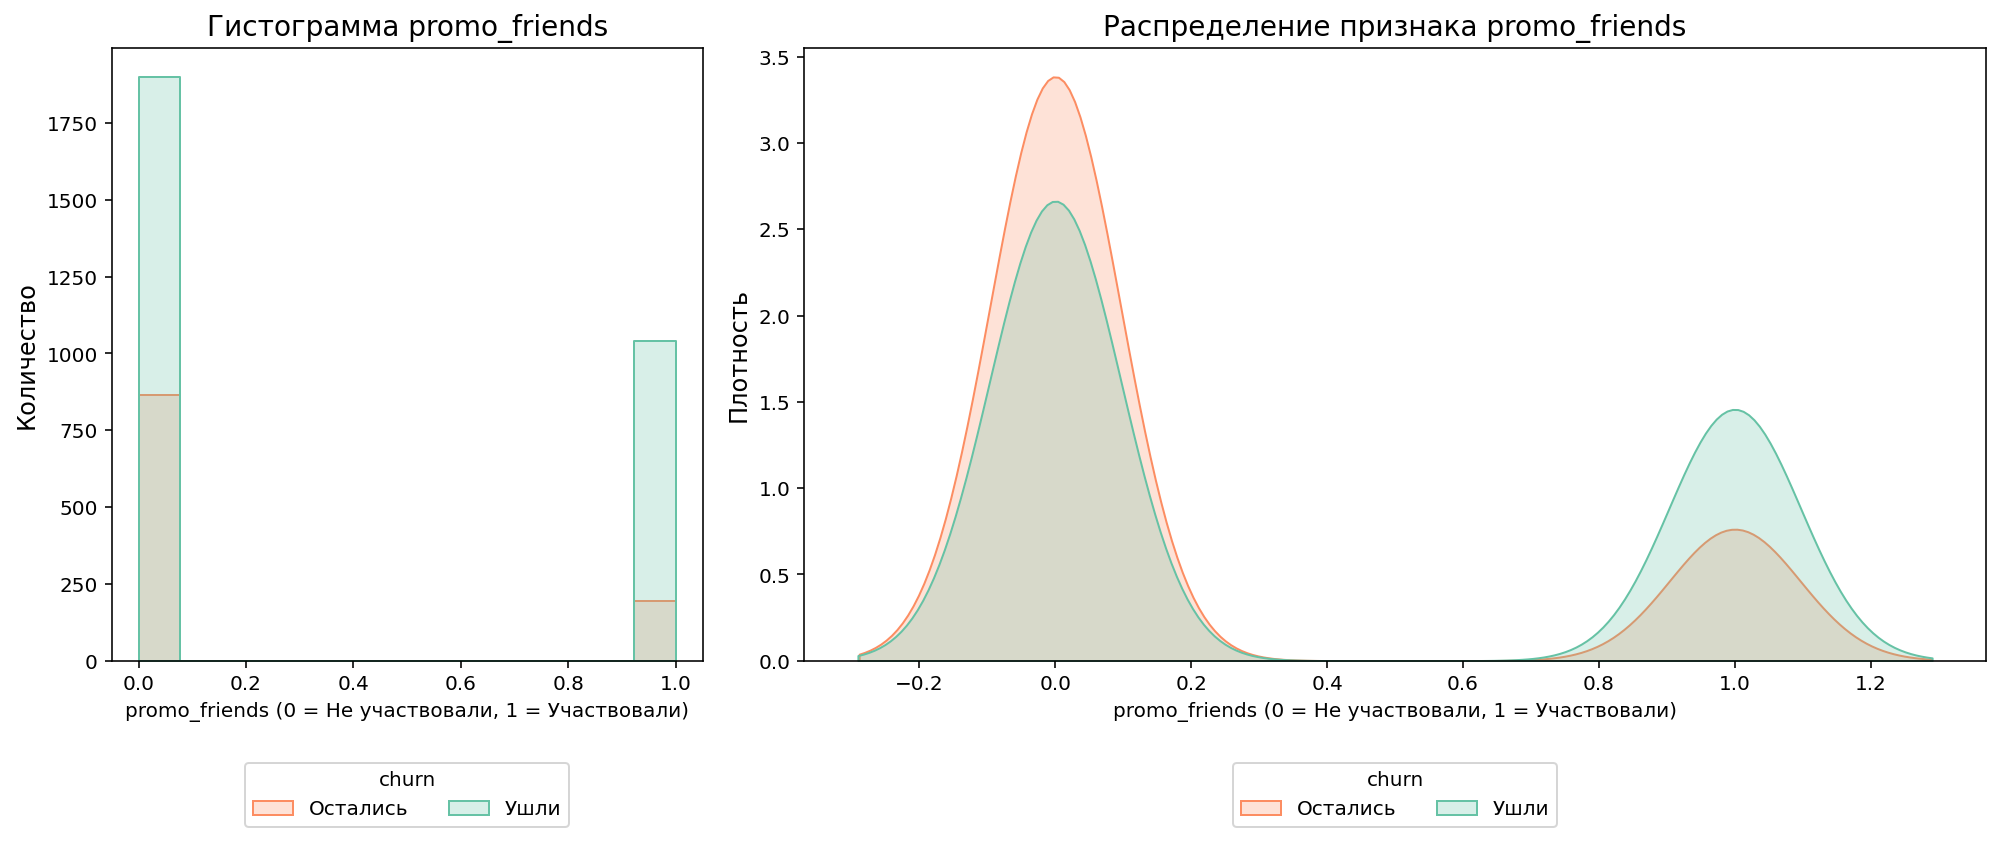

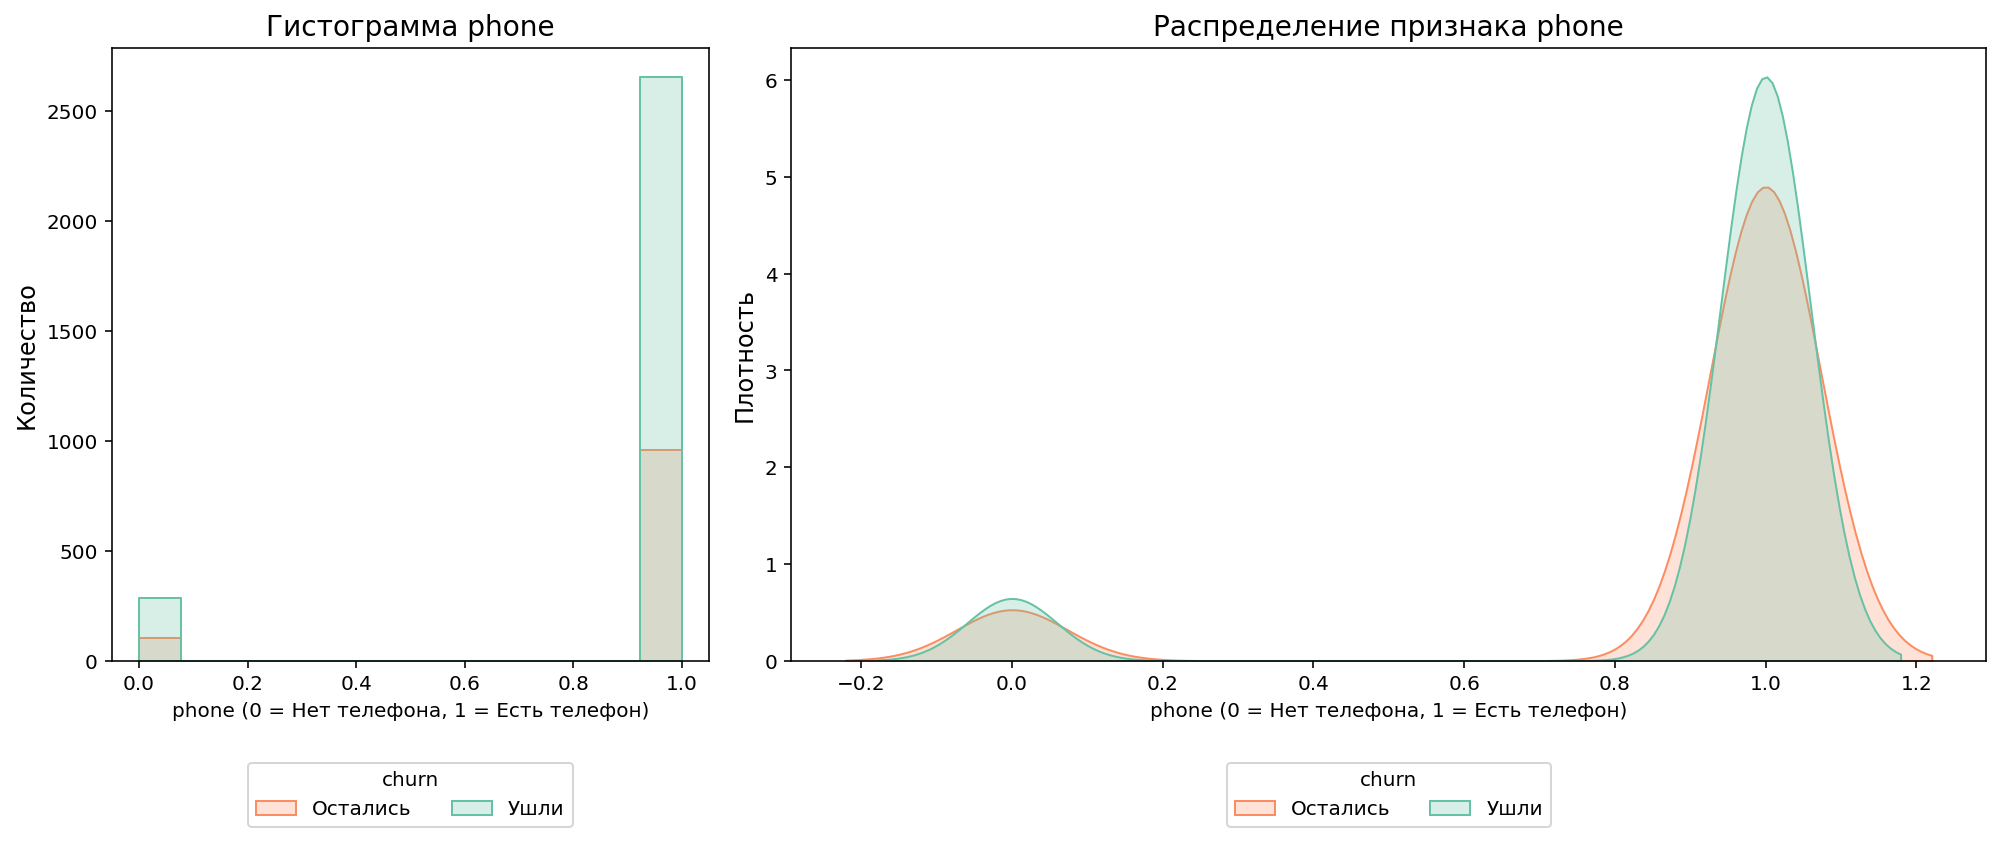

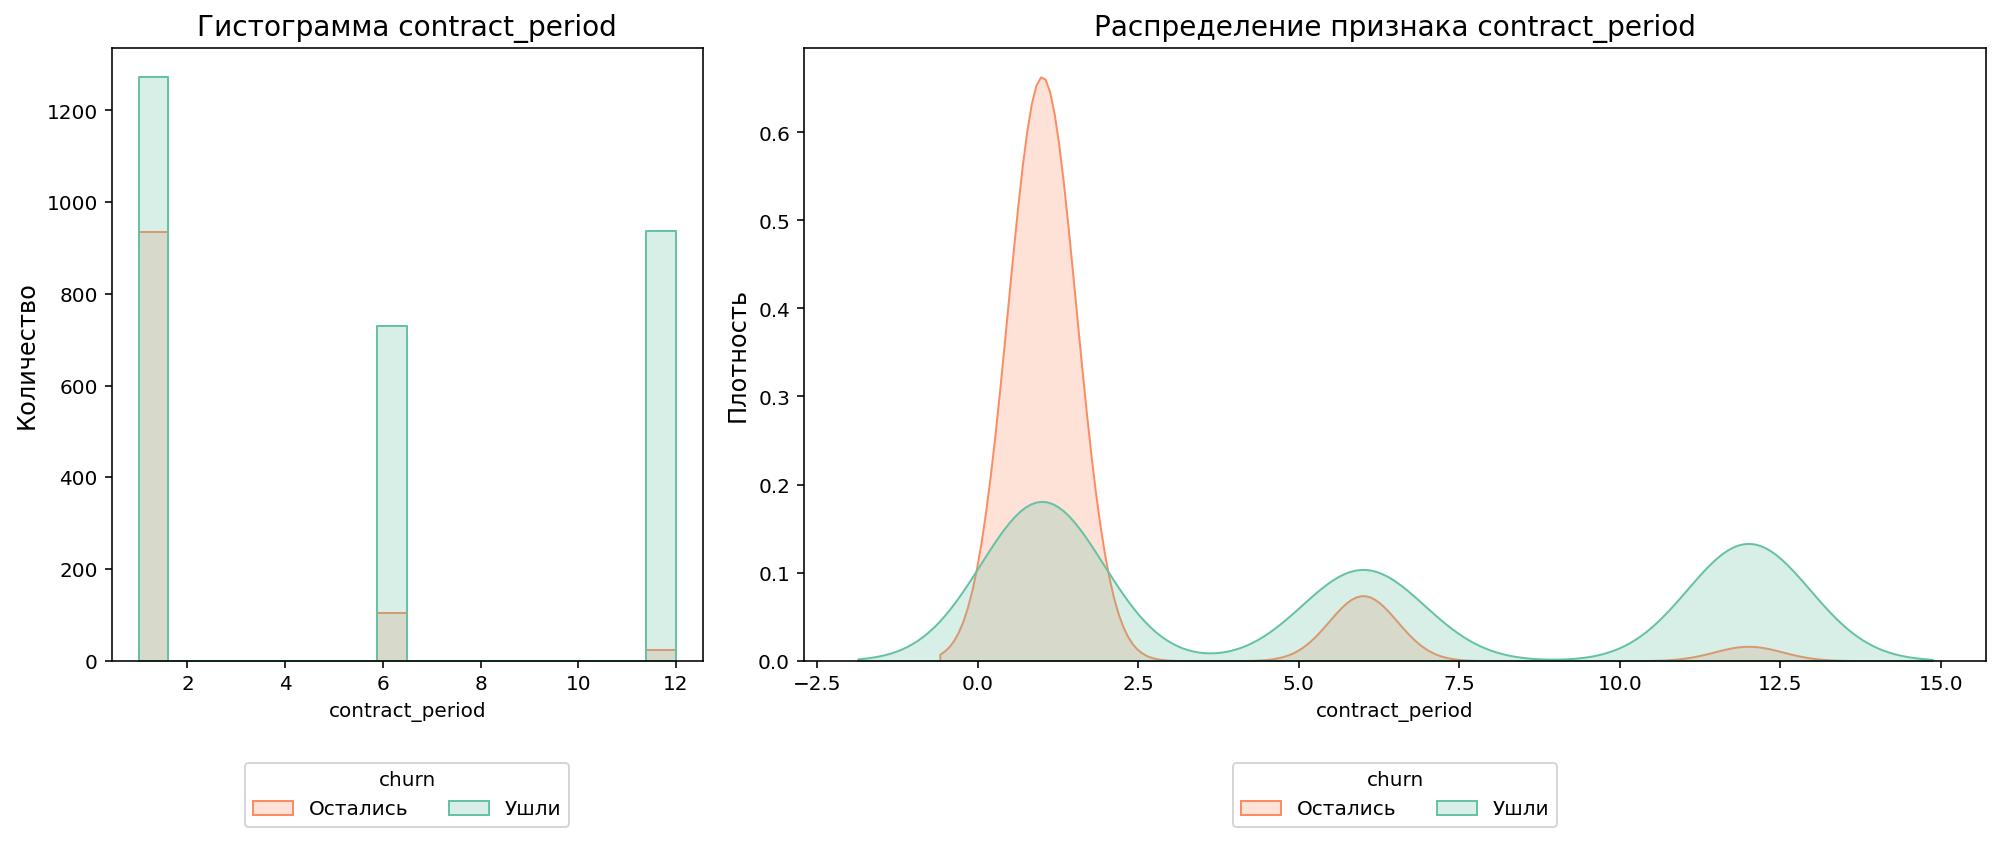

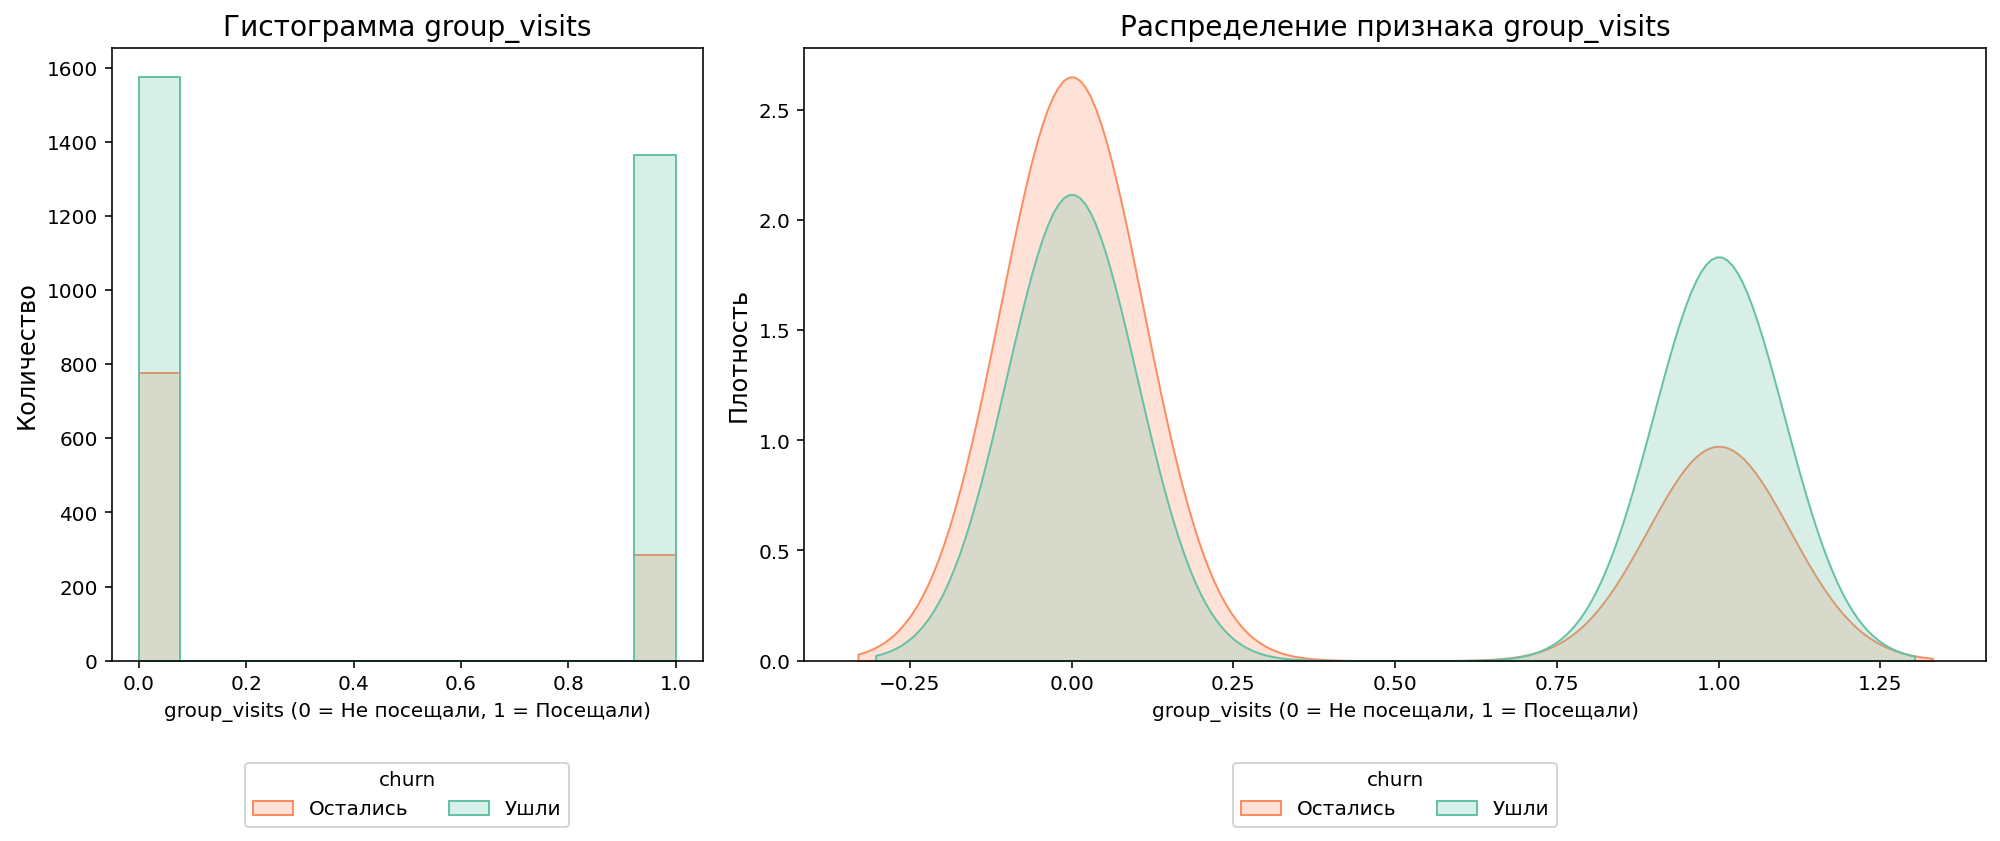

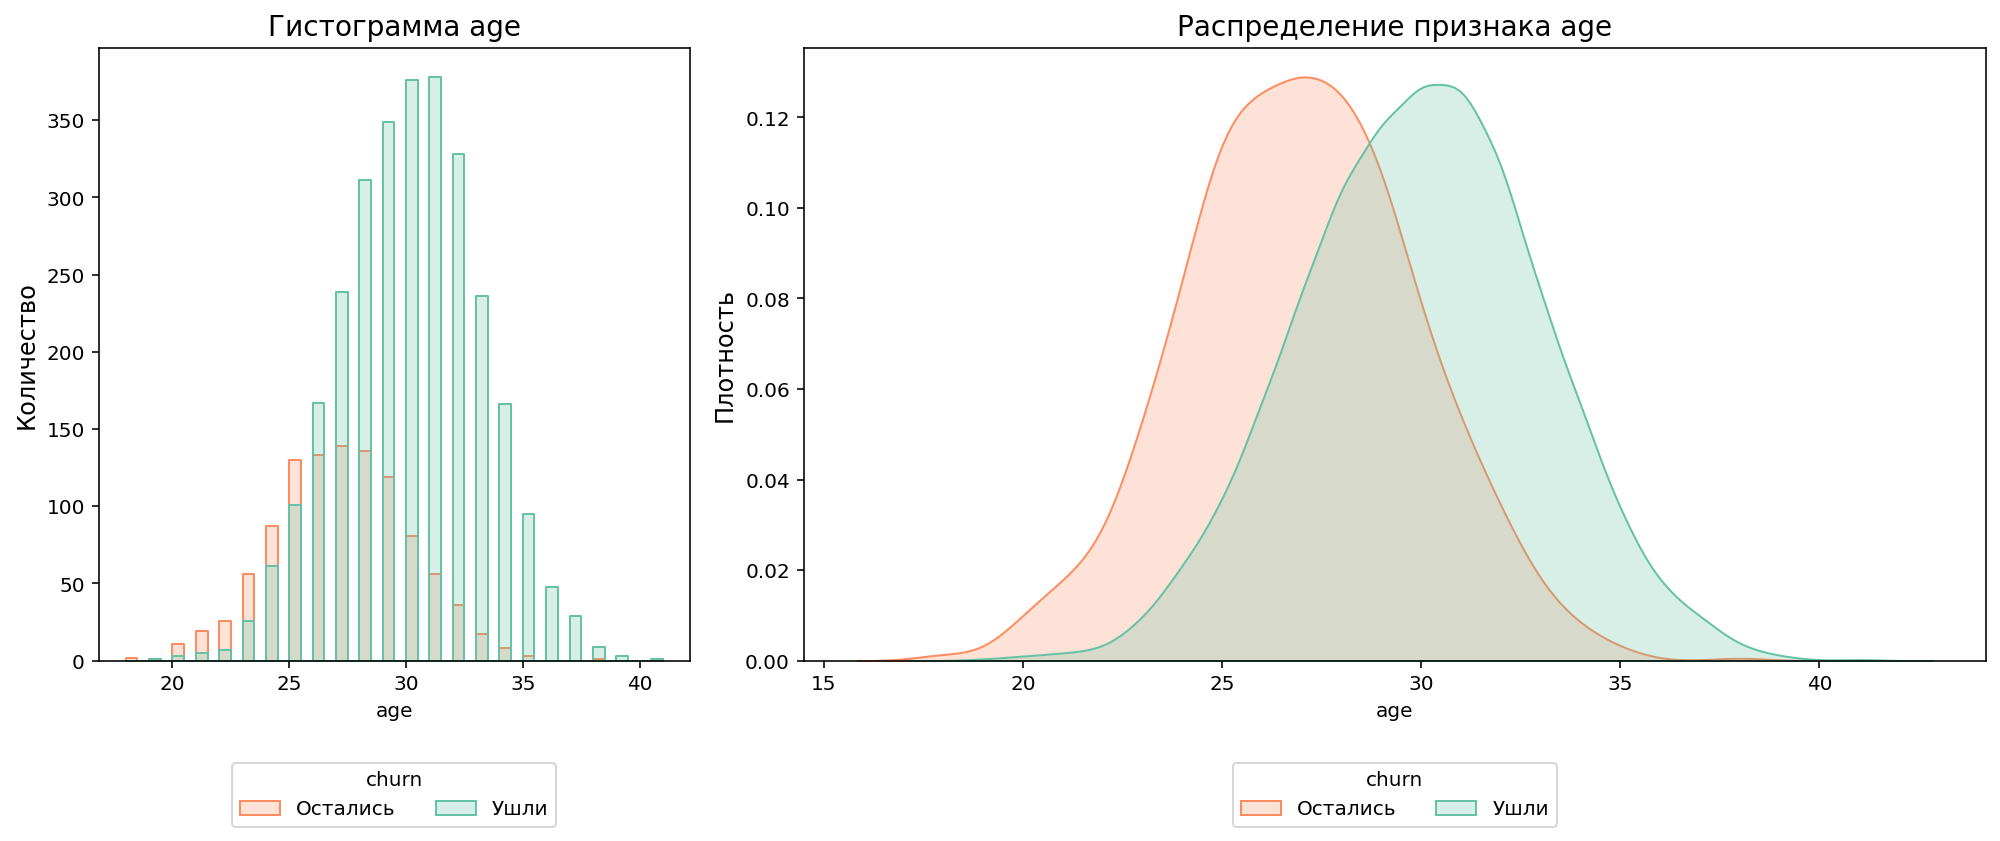

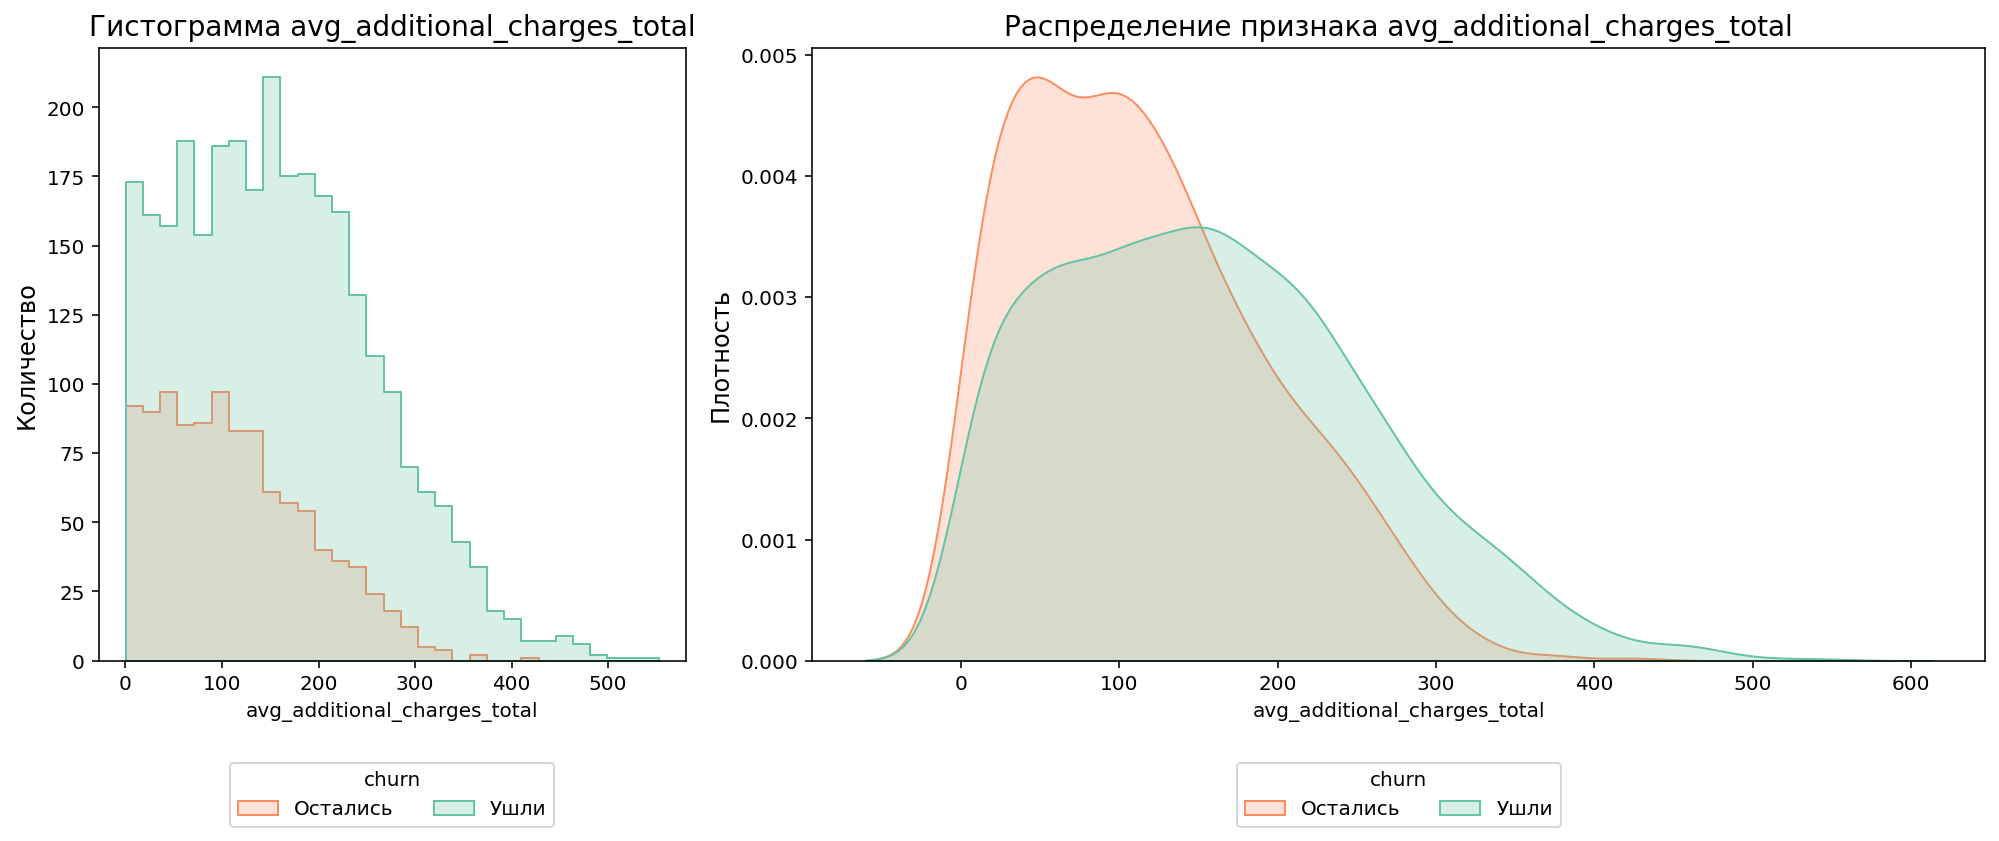

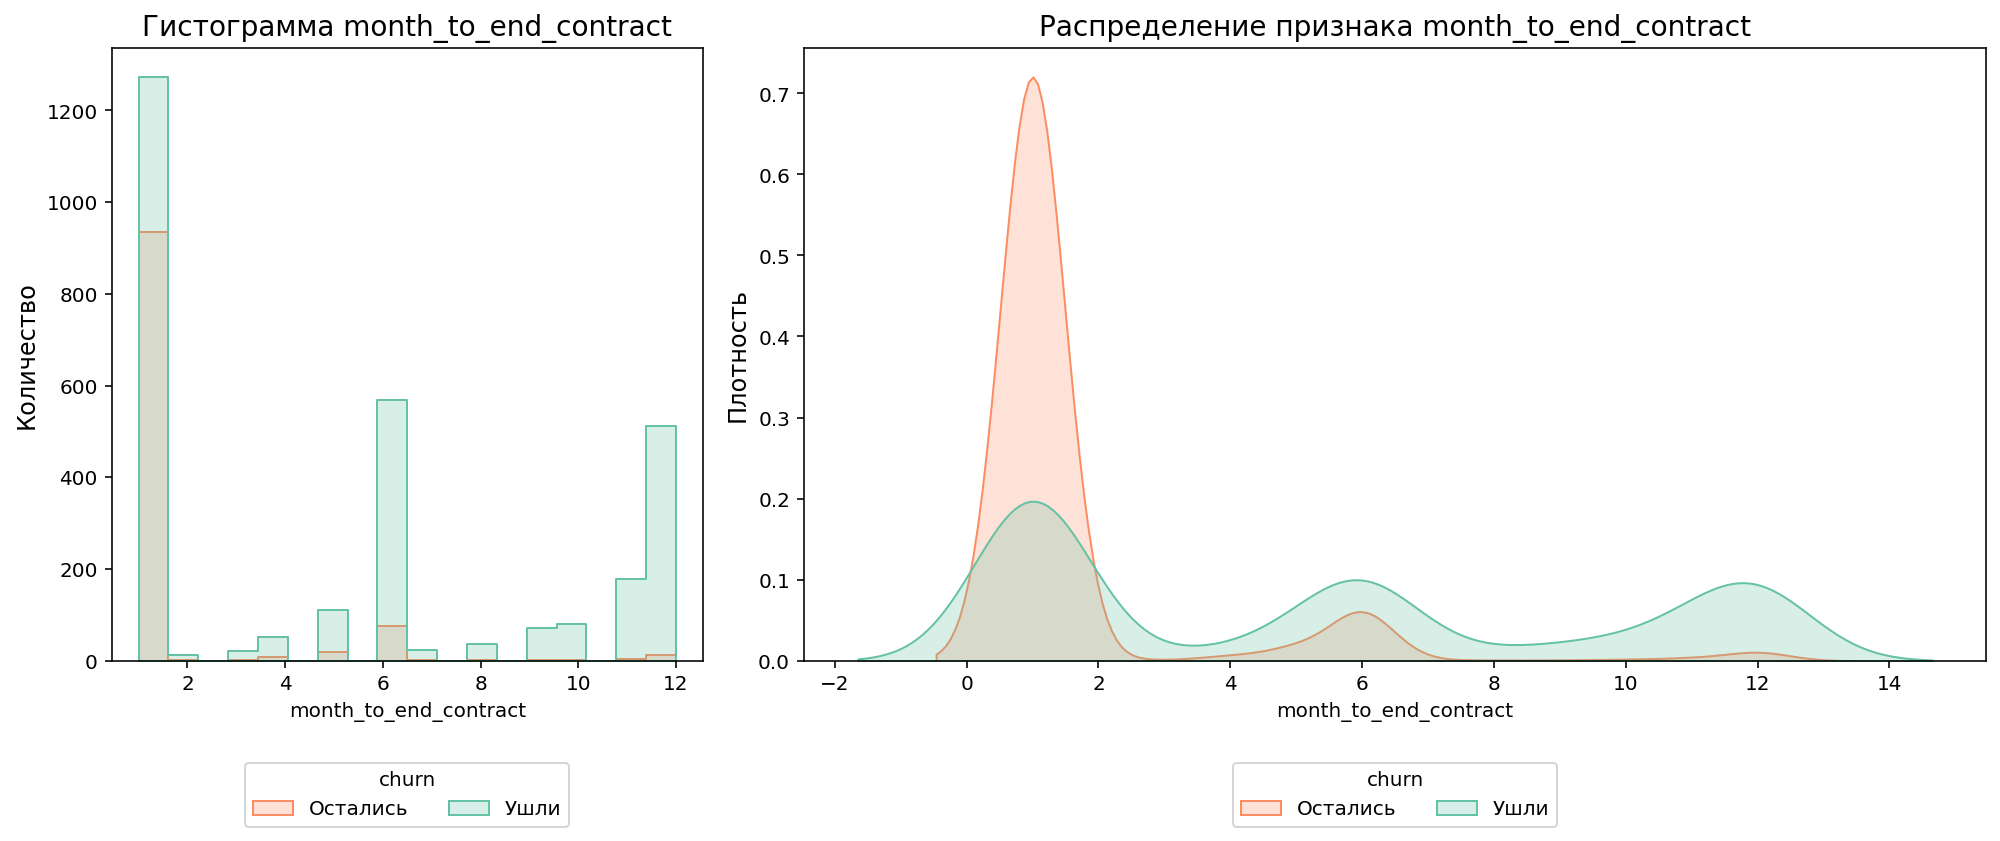

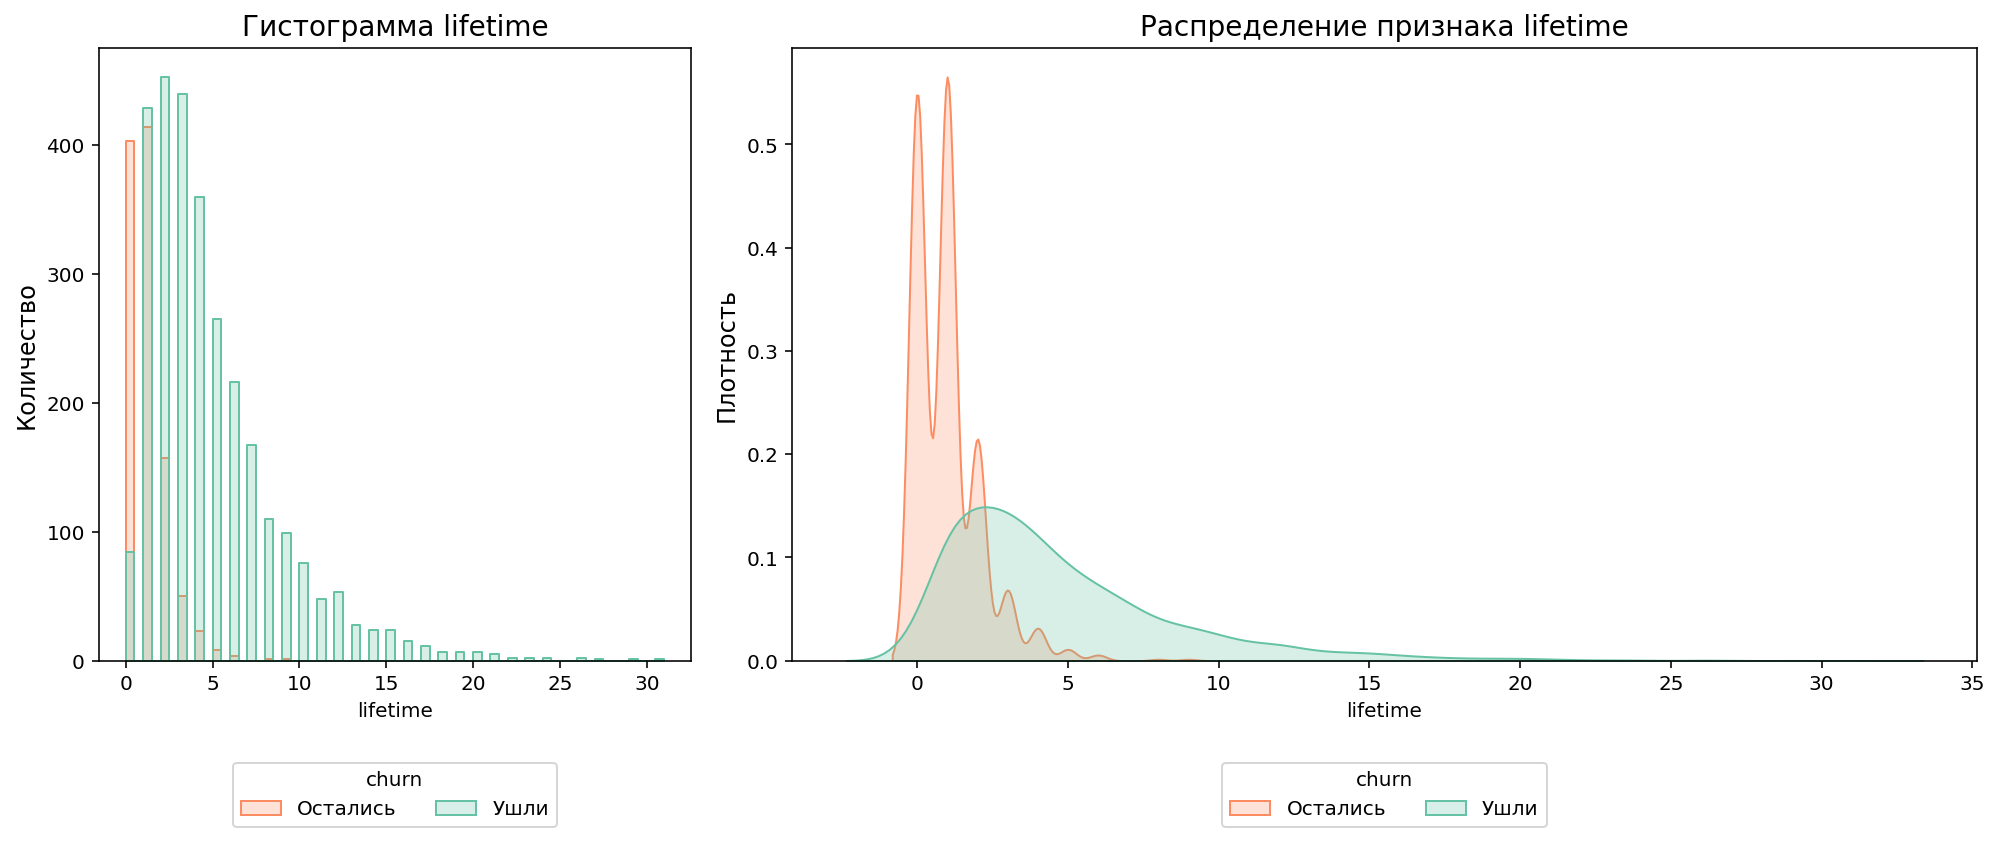

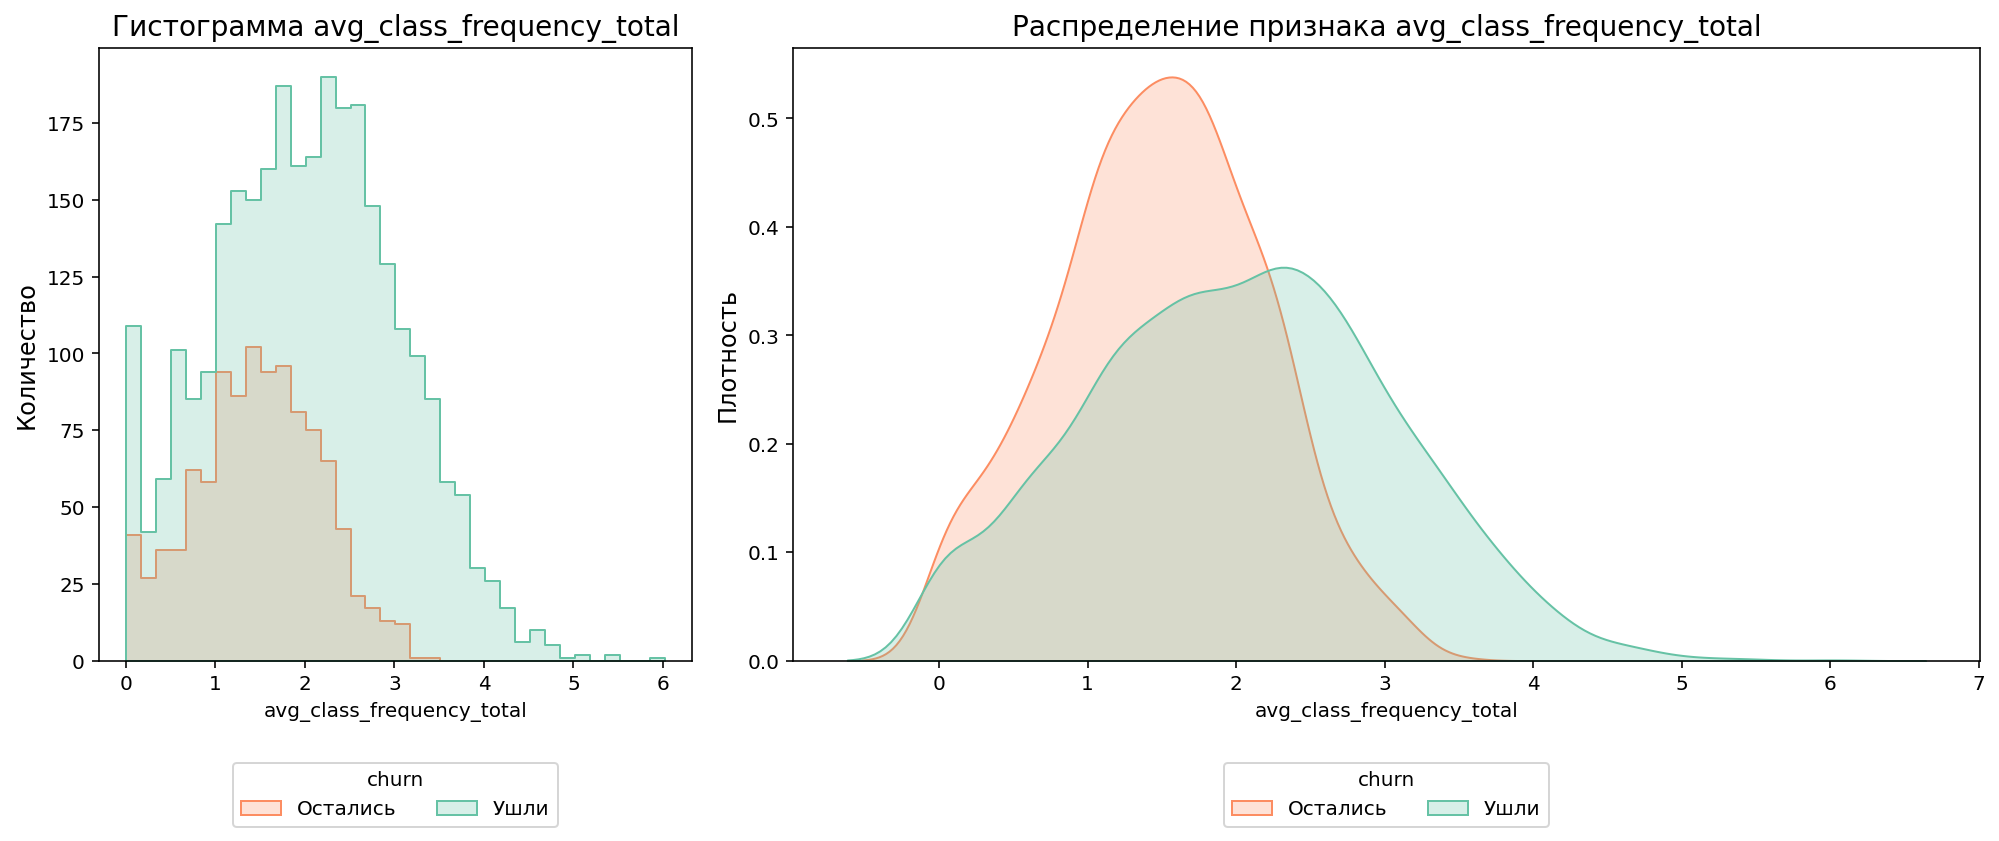

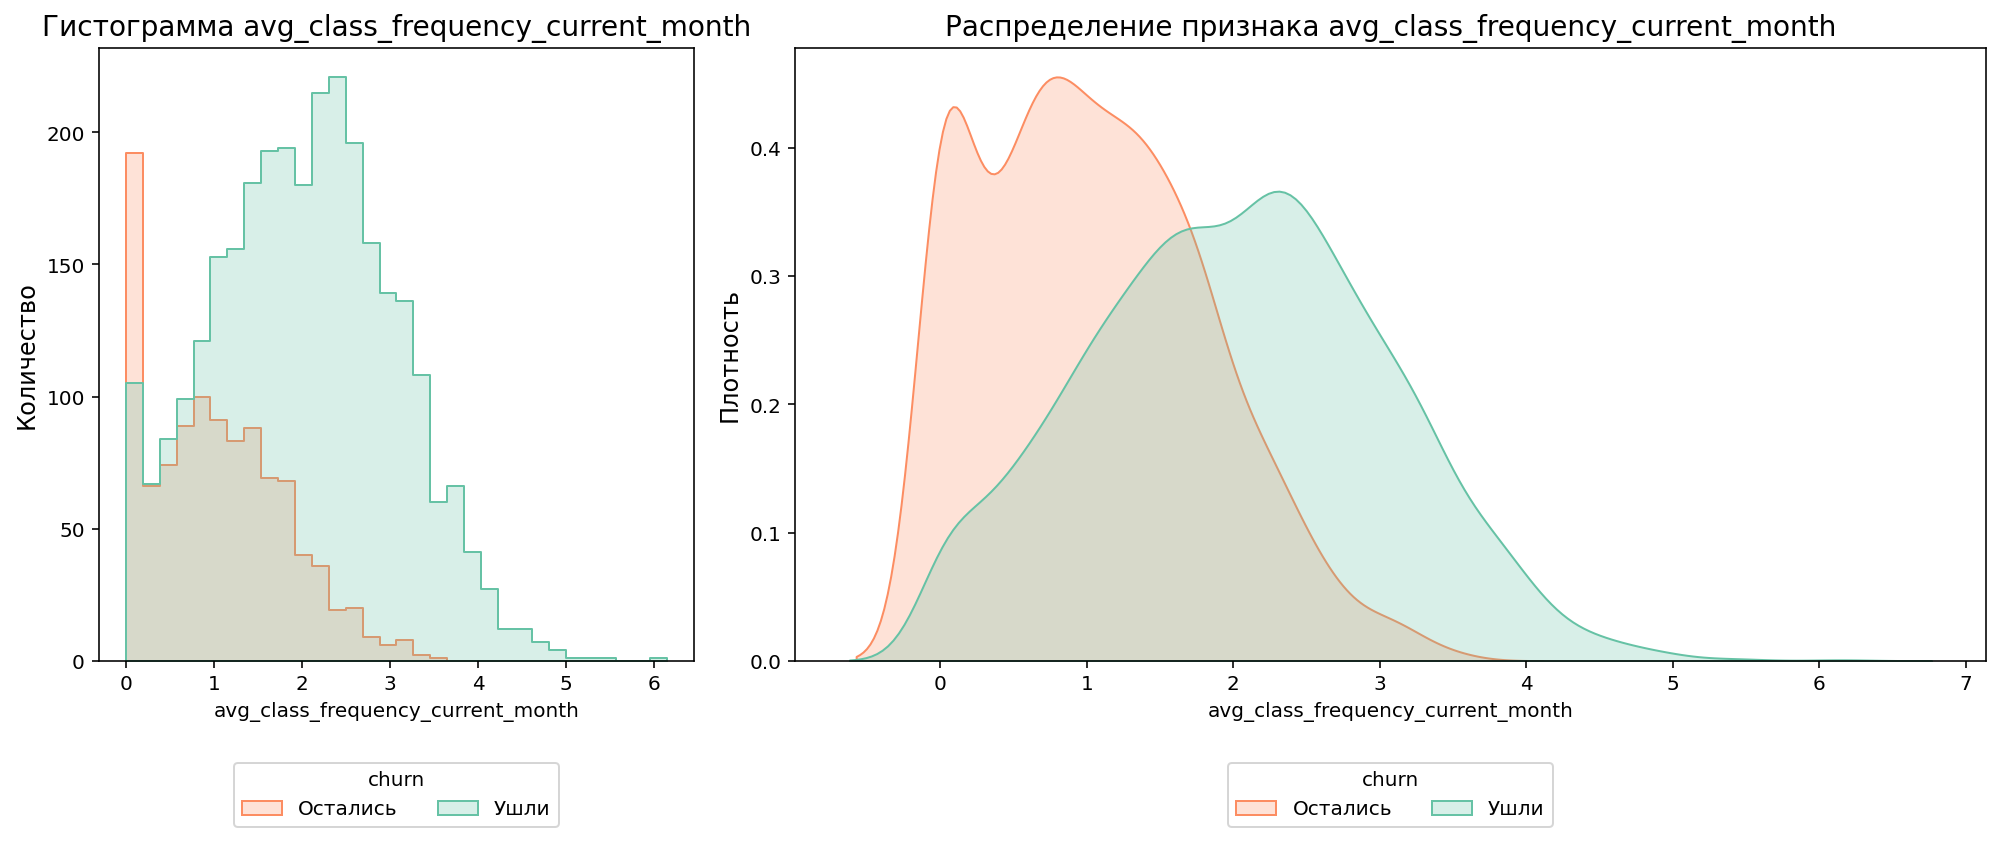

In [8]:
# Словарь для расшифровки бинарных признаков
feature_labels = {
    'gender': 'gender (0 = Мужчины, 1 = Женщины)',
    'near_location': 'near_location (0 = Далеко, 1 = Близко)',
    'partner': 'partner (0 = Без партнёрства, 1 = С партнёрством)',
    'promo_friends': 'promo_friends (0 = Не участвовали, 1 = Участвовали)',
    'phone': 'phone (0 = Нет телефона, 1 = Есть телефон)',
    'group_visits': 'group_visits (0 = Не посещали, 1 = Посещали)'
}

# Функция построения графиков с вынесением легенды за пределы рисунка
def graph_plotting_function(data, target_column, features, feature_labels):
    for feature in features:
        fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [1, 2]})

        # Построение столбчатой гистограммы
        sns.histplot(
            data=data,
            x=feature,
            hue=target_column,
            palette='Set2',
            ax=axes[0],
            element='step'
        )
        axes[0].set_title(f'Гистограмма {feature}', fontsize=14)
        axes[0].set_xlabel(feature, fontsize=12)
        axes[0].set_ylabel('Количество', fontsize=12)
        
        # Добавление подписи под осью X
        explanation = feature_labels.get(feature, feature)  # Получаем расшифровку из словаря
        axes[0].set_xlabel(f'{explanation}', fontsize=10)

        # Вынесение легенды за пределы графика
        axes[0].legend(
            title=target_column,
            labels=['Остались', 'Ушли'],
            bbox_to_anchor=(0.5, -0.15),
            loc='upper center',
            ncol=2
        )
        
        # Построение распределения признака
        sns.kdeplot(
            data=data,
            x=feature,
            hue=target_column,
            palette='Set2',
            ax=axes[1],
            fill=True,
            common_norm=False
        )
        axes[1].set_title(f'Распределение признака {feature}', fontsize=14)
        axes[1].set_xlabel(feature, fontsize=12)
        axes[1].set_ylabel('Плотность', fontsize=12)

        # Добавление подписи под осью X
        axes[1].set_xlabel(f'{explanation}', fontsize=10)

        # Вынесение легенды за пределы графика
        axes[1].legend(
            title=target_column,
            labels=['Остались', 'Ушли'],
            bbox_to_anchor=(0.5, -0.15),
            loc='upper center',
            ncol=2
        )
        # Улучшаем качество графика
        %config InlineBackend.figure_format = 'retina'
        
        plt.tight_layout()
        plt.show()

# Применение функции
numeric_columns = gym_churn.select_dtypes(include=['float64', 'int64']).columns.drop('churn')
graph_plotting_function(gym_churn, target_column='churn', features=numeric_columns, feature_labels=feature_labels)


На предоставленных графиках отображены **данные о клиентах фитнес-центра «Культурист-датасаентист», разделенные по группам: те, кто остался в клубе (отметка "Остались"), и те, кто ушел в отток (отметка "Ушли")**.

Для каждого признака построены два графика:
1. *Слева — Столбчатая гистограмма:*
----
   - Столбцы показывают количество клиентов в каждой группе (остались или ушли) для соответствующего значения признака.
   - Например, для бинарных признаков (`gender`, `near_location`, `partner`) можно видеть, как распределяются клиенты с 0 и 1 значениями по группам.
   - Для непрерывных признаков, таких как `age`, `avg_additional_charges_total`, отображается частотность в диапазоне значений.
----
2. *Справа — Распределение (плотность):*
   - Линии отображают вероятностное распределение значений признака внутри каждой группы.
   - Например, распределение возраста или средней частоты посещений позволяет понять, какие значения более характерны для тех, кто остался или ушел.

**Основные наблюдения:**  
- Для признака `gender` распределение равномерное, и нет ярко выраженной разницы между группами; 
- У тех, кто проживает рядом с клубом (`near_location=1`), вероятность остаться выше, чем уйти;
- Сотрудники компаний-партнеров (`partner=1`) реже покидают клуб;  
- У тех, кто участвовал в акции "Приведи друга" (`promo_friends=1`), отток ниже; 
- Чем дольше длится контракт (`contract_period`) или больше времени до его окончания (`month_to_end_contract`), тем меньше вероятность оттока;
- Групповые занятия (`group_visits`) коррелируют с меньшей вероятностью ухода; 
- Более старшие клиенты (возраст `age`) и те, кто тратит больше на дополнительные услуги (`avg_additional_charges_total`), реже покидают клуб;
- У клиентов с более высоким значением признака `lifetime` (время с момента первого обращения) вероятность остаться значительно выше, чем у тех, у кого этот показатель низкий;  
- Средняя частота посещений за всё время (`avg_class_frequency_total`) и за текущий месяц (`avg_class_frequency_current_month`) тесно связаны с удержанием клиентов: те, кто посещает клуб чаще, реже уходят в отток; 
- У клиентов с минимальными расходами на дополнительные услуги (`avg_additional_charges_total`) вероятность оттока выше, тогда как у тех, кто активно пользуется услугами клуба, вероятность остаться значительно выше.

#### Построение и отображение матрицы корреляций
**Матрица корреляций отображает степень линейной зависимости между признаками в данных**. Построим и отобразим её, используя функцию `plot_correlation_matrix`.

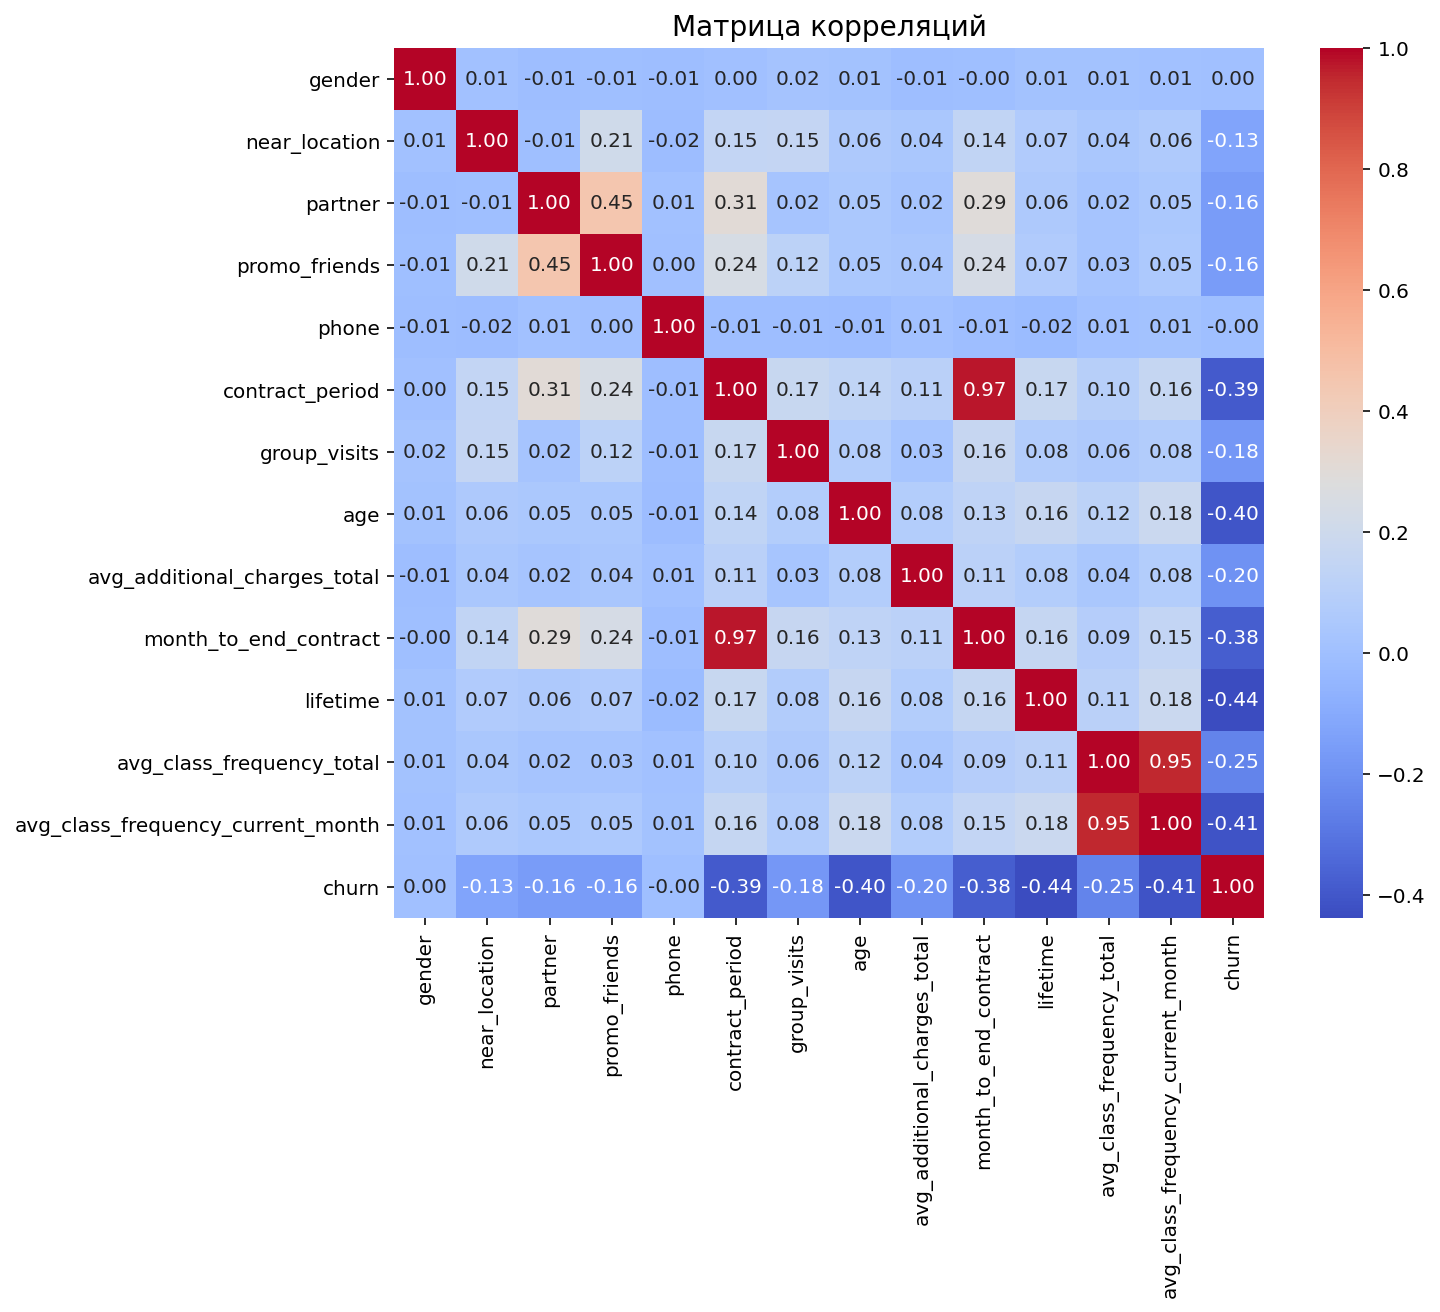

In [9]:
# Построение матрицы корреляций
def plot_correlation_matrix(data):
    plt.figure(figsize=(10, 8))
    correlation_matrix = data.corr() # корреляционая матрица
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True) # отображаем c помощью heatmap
    plt.title('Матрица корреляций', fontsize=14)
    plt.show()
    
# Улучшаем качество графика
%config InlineBackend.figure_format = 'retina'

plot_correlation_matrix(gym_churn)

**Из полученной нами матрицы можно выделить следующие наблюдения:**
- Признаки с высокими значениями корреляции (близкими к 1 или -1) сильно связаны друг с другом. Например, `month_to_end_contract` и `contract_period` имеют корреляцию 0.97, что указывает на почти линейную зависимость. Это логично, так как срок до окончания контракта напрямую зависит от его общей продолжительности.
- Признаки, коррелирующие с оттоком, помогают определить факторы, связанные с вероятностью ухода:
     - `contract_period`: имеет отрицательную корреляцию (-0.39), что говорит о том, что более длинные контракты снижают вероятность оттока.
     - `lifetime`: корреляция -0.44 показывает, что чем дольше клиент является членом клуба, тем ниже вероятность его оттока.
     - `avg_class_frequency_total` и `avg_class_frequency_current_month`: корреляции -0.41 и -0.40 соответственно, что указывает на снижение оттока при более частых посещениях.
- Большинство признаков, таких как `gender`, `phone`, и `age`, имеют слабую или практически отсутствующую корреляцию с оттоком (`churn`). Это говорит о том, что эти признаки сами по себе не являются значимыми индикаторами оттока.
- Высокая корреляция между `avg_class_frequency_total` и `avg_class_frequency_current_month` (0.95) указывает на то, что клиенты, которые посещают клуб часто в целом, сохраняют свою активность в последний месяц.
- Корреляция между `partner` и `promo_friends` (0.45) может быть связана с тем, что сотрудники компаний-партнеров чаще участвуют в акциях клуба.

***Выводы:***
- Наиболее значимые признаки для оттока: `contract_period`, `lifetime`, `avg_class_frequency_total`, `avg_class_frequency_current_month`.
- Некоторые признаки избыточны для анализа (например, `month_to_end_contract` из-за высокой корреляции с `contract_period`).
- Пол (`gender`), наличие телефона (`phone`) и возраст (`age`) оказывают минимальное влияние на вероятность оттока.

 ### Построение модели прогнозирования оттока клиентов
<a id='churn_prediction_model'></a> 
Постром модель бинарной классификации клиентов, где **целевой признак — факт оттока клиента в следующем месяце**:
- Разобьем данные на обучающую и валидационную выборку функцией `train_test_split()`.
- Обучим модель на `train-выборке` двумя способами:
    - логистической регрессией,
    - случайным лесом.
- Оценим метрики `accuracy`, `precision` и `recall` для обеих моделей на валидационной выборке. Сравните по ним модели. Определим, какая модель показала себя лучше на основании метрик.
- При разделении выборки и задании алгоритма укажем параметр `random_state`.

#### Разделение данных на обучающую и валидационную выборки

Разобьем данные на обучающую и валидационную выборку (80:20) функцией `train_test_split()`.

In [10]:
# Разделение данных на обучающую и валидационную выборки
X = gym_churn.drop(columns=['churn'])  # Признаки
y = gym_churn['churn']  # Целевой признак

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

#### Обучение модели логистической регрессии

Обучим модель на train-выборке первым способом: **логистической регрессией**. Т.к. для решения задач методами линейной регрессии данные обязательно стандартизируют, начнем с этого.

In [11]:
# Создаем и обучаем стандартизатор только на обучающей выборке
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Обучаем и масштабируем обучающую выборку
X_val_scaled = scaler.transform(X_val)  # Применяем масштабирование к валидационной выборке

# Обучение логистической регрессии с масштабированными данными
log_reg = LogisticRegression(random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)
y_pred_log_reg = log_reg.predict(X_val_scaled)


#### Обучение модели случайного леса

Теперь обучим модель на train-выборке вторым способом: **случайным лесом**.

In [12]:
# Обучение модели случайного леса
rf = RandomForestClassifier(random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_val)

#### Оценка метрик `accuracy`, `precision` и `recall` для обеих моделей на валидационной выборке

Оценим метрики `accuracy`, `precision` и `recall` для обеих моделей на валидационной выборке. Сравним по ним модели. Определим, какая модель показала себя лучше на основании метрик.

In [13]:
# Оценка метрик для логистической регрессии
accuracy_log_reg = accuracy_score(y_val, y_pred_log_reg)
precision_log_reg = precision_score(y_val, y_pred_log_reg)
recall_log_reg = recall_score(y_val, y_pred_log_reg)

print("Логистическая регрессия:")
print(f"Accuracy: {accuracy_log_reg:.3f}")
print(f"Precision: {precision_log_reg:.3f}")
print(f"Recall: {recall_log_reg:.3f}")

# Оценка метрик для случайного леса
accuracy_rf = accuracy_score(y_val, y_pred_rf)
precision_rf = precision_score(y_val, y_pred_rf)
recall_rf = recall_score(y_val, y_pred_rf)

print("\nСлучайный лес:")
print(f"Accuracy: {accuracy_rf:.3f}")
print(f"Precision: {precision_rf:.3f}")
print(f"Recall: {recall_rf:.3f}")

# Сравнение моделей
print("\nСравнение моделей:")
if accuracy_rf > accuracy_log_reg:
    print("Случайный лес показал лучшее значение accuracy.")
else:
    print("Логистическая регрессия показала лучшее значение accuracy.")

if precision_rf > precision_log_reg:
    print("Случайный лес показал лучшее значение precision.")
else:
    print("Логистическая регрессия показала лучшее значение precision.")

if recall_rf > recall_log_reg:
    print("Случайный лес показал лучшее значение recall.")
else:
    print("Логистическая регрессия показала лучшее значение recall.")

Логистическая регрессия:
Accuracy: 0.916
Precision: 0.873
Recall: 0.782

Случайный лес:
Accuracy: 0.910
Precision: 0.849
Recall: 0.782

Сравнение моделей:
Логистическая регрессия показала лучшее значение accuracy.
Логистическая регрессия показала лучшее значение precision.
Логистическая регрессия показала лучшее значение recall.


Визуализиреум полученные результаты:

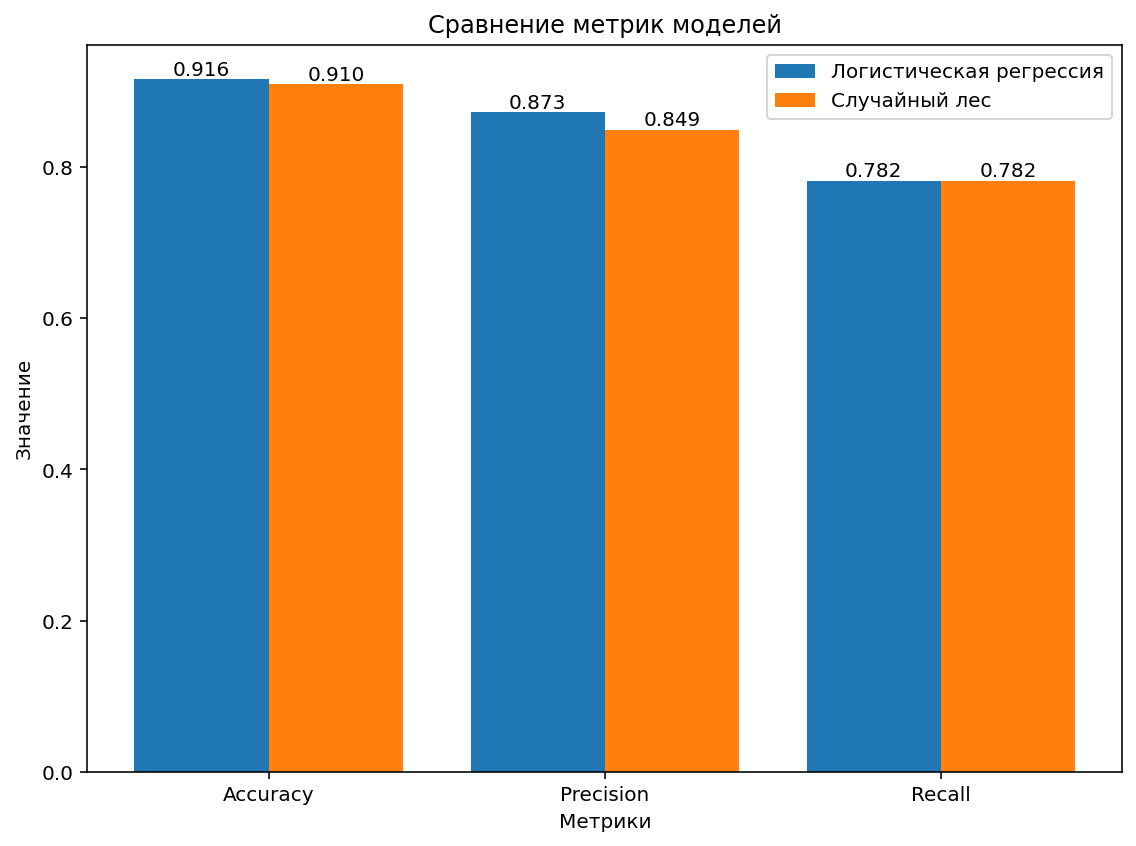

In [14]:
# Метрики для визуализации
metrics = ['Accuracy', 'Precision', 'Recall']
log_reg_scores = [accuracy_log_reg, precision_log_reg, recall_log_reg]
rf_scores = [accuracy_rf, precision_rf, recall_rf]

fig, ax = plt.subplots(figsize=(8, 6))

x = np.arange(len(metrics))  # позиции для столбцов
width = 0.4  # ширина столбцов

# Графики для логистической регрессии и случайного леса
bars1 = ax.bar(x - width / 2, log_reg_scores, width, label='Логистическая регрессия')
bars2 = ax.bar(x + width / 2, rf_scores, width, label='Случайный лес')

# Настройка осей и подписей
ax.set_xlabel('Метрики', fontsize=10)
ax.set_ylabel('Значение', fontsize=10)
ax.set_title('Сравнение метрик моделей', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

# Добавление подписей на столбцы
def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.3f}', ha='center', va='bottom', fontsize=10)

add_value_labels(bars1)
add_value_labels(bars2)

# Улучшаем качество графика
%config InlineBackend.figure_format = 'retina'

plt.tight_layout()
plt.show()

Согласно полученным данным и визуализации, **логистическая регрессия продемонстрировала лучшие результаты по сравнению со случайным лесом во всех метриках**. Она показала чуть более высокую точность классификации (`accuracy = 0.916 против 0.910`) и точность определения положительных классов (`precision = 0.873 против 0.849`), сохранив при этом аналогичный уровень полноты (`recall = 0.782 для обеих моделей`). Однако различия между моделями незначительны, что указывает на схожий уровень их эффективности. **Логистическая регрессия может быть предпочтительна за счёт её интерпретируемости и более простого устройства**.

### Кластеризация клиентов
<a id='client_clusteringn'></a>

#### Стандартизация данных
Используем `StandardScaler` для стандартизации данных. Исключим столбец с оттоком (`churn`) перед стандартизацией.

In [15]:
# Исключаем столбец churn
X = gym_churn.drop(columns=['churn'])

# Стандартизация данных
scaler = StandardScaler() # создаём объект класса scaler для стандартизации
X_scaled = scaler.fit_transform(X)

На выходе получим преобразованные таблицы объект-признак для обучающего и валидационного набора. И уже их будем применять для обучения и прогнозирования.

#### Построение матрицы расстояний и дендрограммы
Построим матрицу расстояний функцией `linkage()` на стандартизованной матрице признаков и нарисуем дендрограмму.   
На основании полученного графика предположим, какое количество кластеров можно выделить.

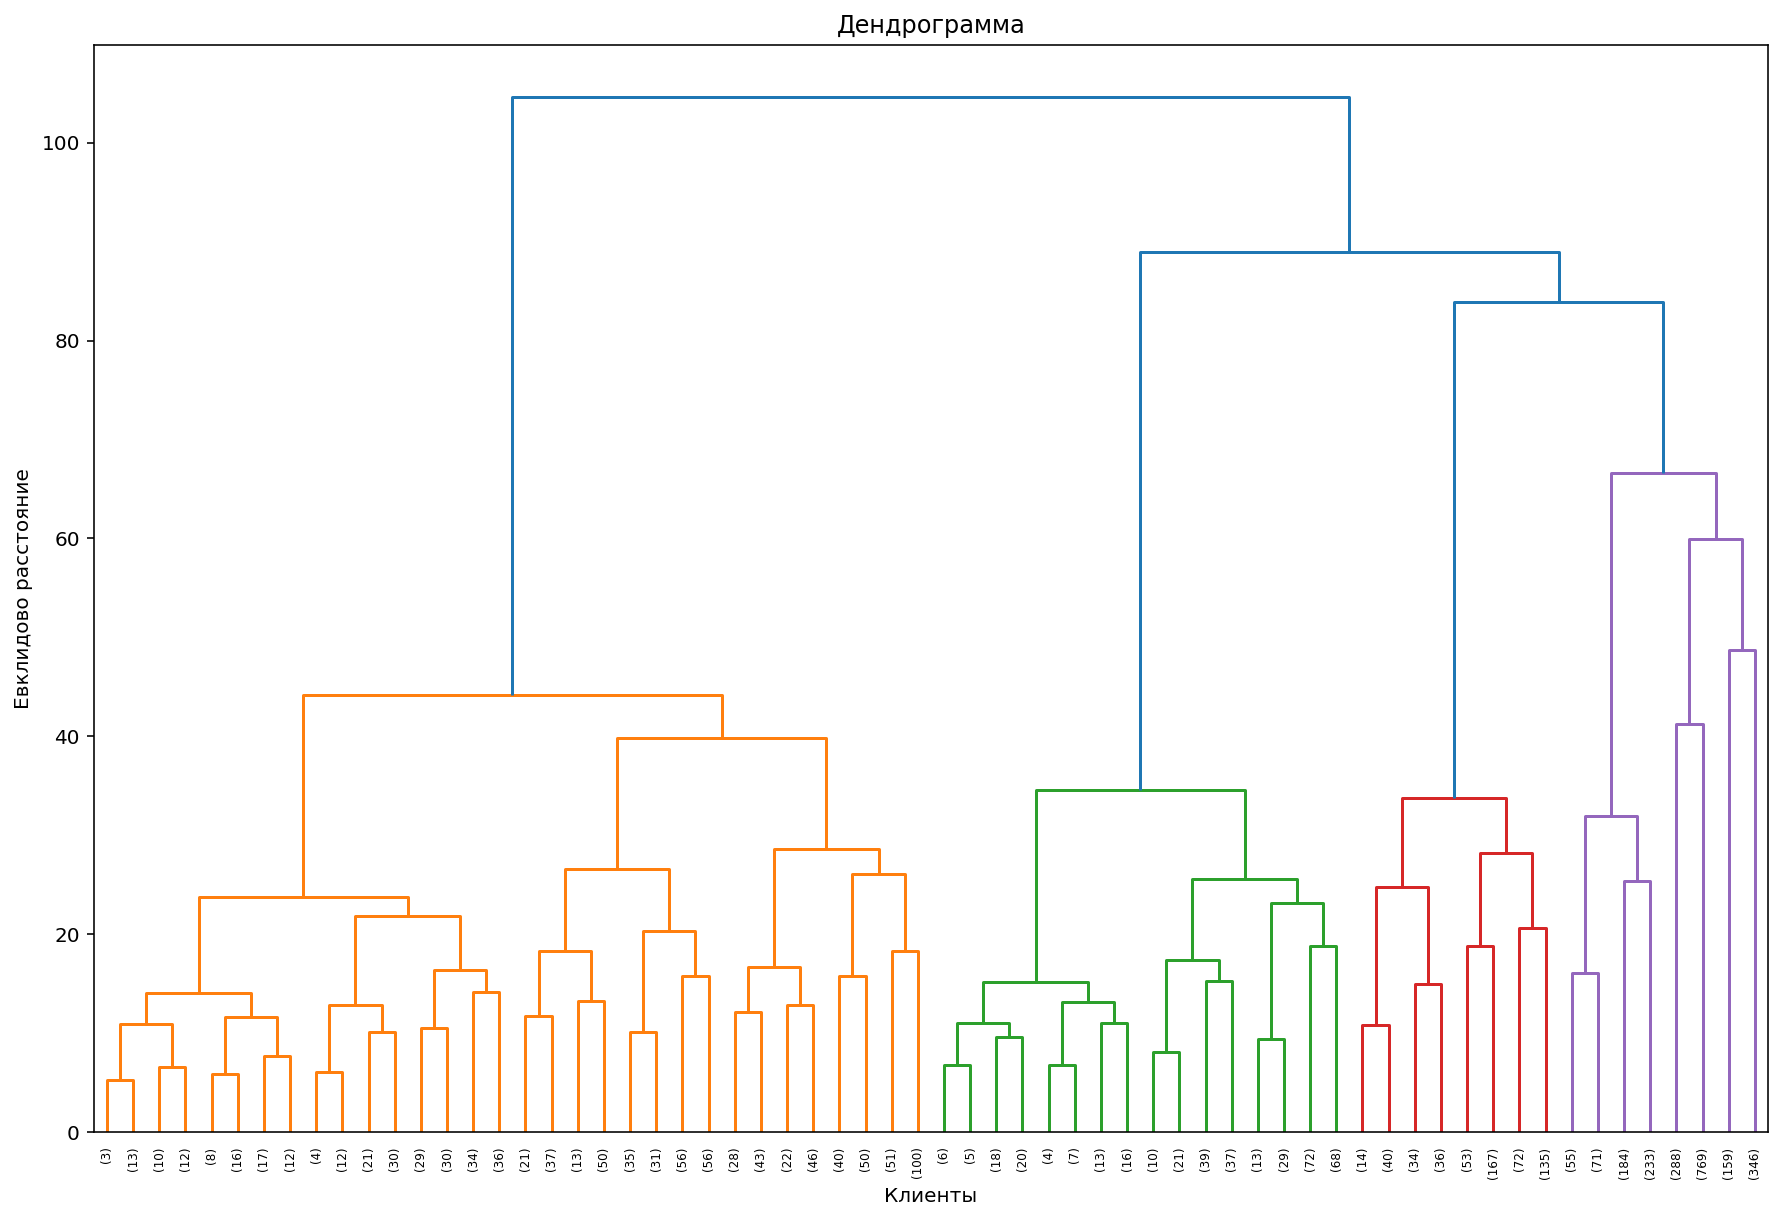

In [16]:
# Построение матрицы расстояний и дендрограммы
linked = linkage(X_scaled, method='ward') # в переменной linked сохранена таблица «связок» между объектами

plt.figure(figsize=(15, 10))
dendrogram(linked, truncate_mode='level', p=5)
plt.title('Дендрограмма')
plt.xlabel('Клиенты')
plt.ylabel('Евклидово расстояние')
plt.show()

# Улучшаем качество графика
%config InlineBackend.figure_format = 'retina'

На основании дендрограммы **можно выделить 4–5 кластеров, так как на уровне расстояния около 50 видны явные разрывы**, которые разделяют данные на основные группы. Эти разрывы визуально делят дендрограмму на кластеры. Если выбрать 5 кластеров, разбиение будет более детализированным.

#### Обучение модели `K-Means`
Обучим модель кластеризации на основании алгоритма `K-Means` и спрогнозируем кластеры клиентов (число кластеров примем как `n=5`, чтобы полученные результаты можно было сравнивать с результатами остальных студентов).

In [17]:
# Обучение модели K-Means
km = KMeans(n_clusters=5, random_state=RANDOM_STATE) # задаём число кластеров, равное 5, и фиксируем значение random_state для воспроизводимости результата
labels = km.fit_predict(X_scaled) # применяем алгоритм к данным и формируем вектор кластеров 

# Добавление меток кластеров в исходный датасет
gym_churn['cluster'] = labels

Модель кластеризации обучена на основании алгоритма K-Means, посмотрим на средние значения признаков для кластеров.

#### Средние значения признаков для кластеров
Используем метод `groupby()` для анализа средних значений признаков по кластерам.

In [18]:
# Средние значения признаков для кластеров
cluster_means = gym_churn.groupby('cluster').mean()
display(cluster_means)

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn
cluster,,,,,,,,,,,,,,
0,0.502370,0.949447,0.829384,0.998420,1.0,3.097946,0.448657,29.104265,141.774331,2.887836,3.772512,1.770536,1.669581,0.246445
1,0.554556,0.849269,0.263217,0.052868,1.0,2.606299,0.436445,30.008999,159.774265,2.419573,4.780652,2.745505,2.733173,0.089989
2,0.499422,0.937572,0.737572,0.478613,1.0,11.854335,0.546821,29.905202,163.509804,10.812717,4.677457,2.006405,1.998179,0.021965
3,0.485738,0.718011,0.299919,0.018745,1.0,1.914425,0.276284,28.083945,129.496414,1.821516,2.195599,1.225192,0.967967,0.572942
4,0.523316,0.862694,0.471503,0.305699,0.0,4.777202,0.427461,29.297927,144.208179,4.466321,3.940415,1.854211,1.723967,0.266839


**На основании предоставленных средних значений признаков для каждого кластера можно выделить следующие наблюдения:**

 *Кластер 0*:
   - Высокая доля клиентов, проживающих рядом с клубом (`near_location=0.949`);
   - Высокий показатель участия в акции "Приведи друга" (`promo_friends=0.998`);
   - Средняя длительность контракта (`contract_period=3.1`) и небольшая доля групповых посещений (`group_visits=0.449`);
   - Умеренный уровень оттока (`churn=0.246`).

*Кластер 1*:
   - Низкий показатель участия в акции "Приведи друга" (`promo_friends=0.053`);
   - Средний возраст клиентов самый высокий среди всех кластеров (`age=30.0`);
   - Низкая доля оттока (`churn=0.090`), что указывает на надежность клиентов;
   - Высокая частота посещений (`avg_class_frequency_total=2.746`) и высокая активность в текущем месяце.

*Кластер 2*:
   - Самая высокая длительность контракта (`contract_period=11.85`) и срок до окончания контракта (`month_to_end_contract=10.81`);
   - Высокий уровень отложенных расходов (`avg_additional_charges_total=163.51`);
   - Самая низкая доля оттока среди всех кластеров (`churn=0.022`), что говорит о стабильных и лояльных клиентах.

*Кластер 3*:
   - Самый высокий показатель оттока (`churn=0.573`);
   - Низкая доля участия в программе "Приведи друга" (`promo_friends=0.019`);
   - Самый низкий срок контракта (`contract_period=1.91`) и частота посещений (`avg_class_frequency_total=1.225`);
   - Этот кластер представлен клиентами с минимальной вовлеченностью.

*Кластер 4*:
   - Средние значения по большинству признаков;
   - Относительно высокий уровень оттока (`churn=0.267`);
   - Характеристики близки к общим, что может свидетельствовать о средней вовлеченности клиентов.

**Основные выводы:**
- **Кластеры 1 и 2** имеют наиболее надежных клиентов с низкой долей оттока.
- **Кластер 3** демонстрирует наибольшую склонность к оттоку, клиенты этого кластера менее вовлечены.
- Участие в программе "Приведи друга" и более длительные контракты положительно сказываются на удержании клиентов.
- Расходы на дополнительные услуги также связаны с более низким уровнем оттока.

#### Распределение признаков для кластеров
Построим распределения для каждого признака, разделённого по кластерам. Определим, можно ли что-то заметить по ним.

Когда кластеров больше трех, на одном графике несколько гистограмм читаются сложно, поэтому построим визуализацию с помощью библиотеки `plotly` (гистрограммы и боксплот в числовых признаках).

In [ ]:
# Словарь для расшифровки бинарных признаков
feature_labels = {
    'gender': 'gender (0 = Мужчины, 1 = Женщины)',
    'near_location': 'near_location (0 = Далеко, 1 = Близко)',
    'partner': 'partner (0 = Без партнёрства, 1 = С партнёрством)',
    'promo_friends': 'promo_friends (0 = Не участвовали, 1 = Участвовали)',
    'phone': 'phone (0 = Нет телефона, 1 = Есть телефон)',
    'group_visits': 'group_visits (0 = Не посещали, 1 = Посещали)'
}

# Признаки, для которых нужно добавить боксплот
features_with_boxplot = [
    'age', 
    'avg_additional_charges_total', 
    'lifetime', 
    'avg_class_frequency_total', 
    'avg_class_frequency_current_month'
]

# Список всех признаков для анализа
features = gym_churn.columns.tolist()

# Цикл для построения графиков по каждому признаку
for feature in features:
    # Проверяем, есть ли расшифровка для текущего признака
    explanation = feature_labels.get(feature, feature)
    
    # Проверяем, нужно ли добавлять боксплот для текущего признака
    marginal_option = 'box' if feature in features_with_boxplot else None

    # Построение графика
    fig = px.histogram(
        gym_churn,
        x=feature,
        color='cluster',  # Кластеры для раскраски
        marginal=marginal_option,  # Добавляем боксплот только для указанных признаков
        opacity=0.5,  # Прозрачность столбцов
        barmode='group',  # Группировка
        title=f'Распределение значений столбца {explanation} с разделением по кластерам'
    )
    fig.update_layout(
        xaxis_title=explanation,  # Название оси X с расшифровкой
        yaxis_title='Количество',  # Название оси Y
        legend_title='Кластеры',  # Название легенды
        template='plotly_white'  # Стиль
    )
    fig.show()

# Улучшаем качество графика
%config InlineBackend.figure_format = 'retina'

**На основании построенных распределений признаков для кластеров можно сделать следующие наблюдения:**
- **`gender`**. Распределение по полу практически одинаково во всех кластерах. Это может говорить о том, что пол не является ключевым фактором, определяющим принадлежность клиента к кластеру;
- **`near_location`**. Большинство клиентов из всех кластеров находятся рядом с фитнес-клубом (значение 1). Однако для некоторых кластеров (например, Кластера 3) доля клиентов, проживающих далеко (значение 0), немного выше;
-  **`partner`**. Кластеры 0 и 1 имеют высокую долю клиентов, состоящих в партнёрских отношениях (значение 1). В остальных кластерах количество клиентов без партнёрства больше;
- **`promo_friends`**. Для Кластера 1 почти все клиенты участвовали в акции «Приведи друга» (значение 1). В других кластерах наблюдается меньшая доля участников акции;
- **`contract_period`**. У Кластера 3 доминирует длительный период контракта (ближе к 12 месяцам). В остальных кластерах распространены более короткие контракты;
- **`group_visits`**. Посещение групповых занятий выше в Кластерах 1 и 0, что может говорить о заинтересованности клиентов этих кластеров в дополнительных активностях;
- **`age`**. Возраст клиентов относительно схож во всех кластерах, с небольшими различиями: Кластеры 0 и 3 имеют чуть моложе клиентов, чем остальные;
- **`avg_additional_charges_total`**. Средние дополнительные траты выше в Кластере 3, что может свидетельствовать о большей заинтересованности этих клиентов в дополнительных услугах клуба;
- **`month_to_end_contract`**. Клиенты Кластера 3 в среднем имеют больше месяцев до окончания контракта, что коррелирует с их долгосрочными контрактами;
- **`lifetime`**. В Кластере 3 клиенты имеют более продолжительный период взаимодействия с клубом. В других кластерах этот показатель ниже, особенно в Кластере 4;
- **`avg_class_frequency_total`** и **`avg_class_frequency_current_month`**. В Кластере 3 средняя частота посещений как за весь период, так и за текущий месяц выше, чем в других кластерах. Кластеры 0 и 1 также имеют высокие частоты посещений, тогда как Кластер 4 имеет самые низкие значения;
- **`churn`**. В Кластере 4 отмечена самая высокая доля клиентов, покинувших клуб. В Кластере 3, напротив, наименьший уровень оттока, что может говорить о высокой лояльности этих клиентов.

**Общие выводы:**
- Кластеры явно различаются по признакам, связанным с поведением и активностью клиентов (частота посещений, использование дополнительных услуг, участие в акциях, длительность контрактов);
- Лояльность клиентов можно связать с их активностью: более активные клиенты (Кластер 3) реже уходят в отток;
- Кластер 4 характеризуется меньшей вовлечённостью клиентов, что приводит к более высокой доле оттока.

#### Доля оттока по кластерам
Для каждого полученного кластера посчитаем общее количество клиентов, количество ушедших клиентов и долю (%) оттока (отразим сводной таблицей, методом `pivot_table()`). Посмотрим, отличаются ли они по доле оттока, определим, какие кластеры склонны к оттоку, а какие — надёжны.

In [ ]:
# Доля оттока по кластерам
churn_by_cluster = gym_churn.pivot_table(index = 'cluster', values = 'churn', aggfunc = ['count', 'sum', 'mean'])

# Переименовывоем столбцы
churn_by_cluster.columns = ['Общее кол-во клиентов', 'Кол-во ушедших клиентов', '% оттока']

print("Доля оттока по кластерам:")
churn_by_cluster.style.format({'% оттока':'{:.1%}'}) # вывод % с 1 знаком после запятой

**Доля оттока заметно отличается между кластерами**.

`Кластер 3` демонстрирует самую высокую долю оттока (`57.3%`), что указывает на **слабую лояльность клиентов**. **Умеренная доля оттока** наблюдается в `Кластерах 4` (26.7%) и `0` (24.6%), что требует внимания. `Кластеры 2` (2.2%) и `1` (9.0%) показывают **низкую долю оттока**, что свидетельствует о высокой лояльности и их надёжности. 

`Кластеры 1` и `2` можно считать **ориентированными на долгосрочное сотрудничество**, тогда как для `кластеров 3` и `4` **стоит разработать стратегии по снижению оттока**.

### Выводы и  базовые рекомендации по работе с клиентами
<a id='conclusions_recommendations'></a>
#### Основные выводы
1. Клиенты распределены по кластерам с различной долей оттока. Наиболее надёжные кластеры — 2 (2.2%) и 1 (9.0%), тогда как кластер 3 имеет высокий уровень оттока (57.3%), что свидетельствует о слабой лояльности клиентов этой группы.
2. Лояльные клиенты чаще проживают рядом с клубом, участвуют в партнёрских программах и акциях, имеют более длительные контракты и регулярно посещают клуб.
3. Высокий отток характерен для клиентов с короткими контрактами, низкой вовлечённостью в дополнительные услуги, а также с низкой частотой посещений.

#### Рекомендации
1. **Индивидуализация подхода к клиентам в кластере с высоким оттоком (Кластер 3)**:
   - Проведение персонализированных акций, таких как продление контрактов с бонусами или скидками при оплате за более длительный период;
   - Введение программ лояльности для клиентов с коротким сроком контрактов, например, бесплатные дополнительные услуги или пробные занятия.

2. **Стимулирование вовлечённости клиентов**:
   - Разработка мотивационных программ для увеличения частоты посещений, таких как система бонусов за количество визитов или групповые активности.
   - Продвижение дополнительных услуг клуба, например, скидок на тренировки или спа-процедуры для клиентов с низким уровнем трат на дополнительные услуги.

3. **Акцент на удержание клиентов из надёжных кластеров (Кластеры 1 и 2)**:
   - Поддержание их лояльности через регулярные программы «для постоянных клиентов», например, эксклюзивные мероприятия или доступ к закрытым клубным зонам.
   - Упрощение процесса продления контрактов, включая автоматическое продление с дополнительными бонусами.

4. **Увеличение участия в акциях и партнёрских программах**:
   - Активное продвижение акций «Приведи друга» для клиентов с низким уровнем вовлечённости (Кластеры 0 и 4).
   - Расширение партнёрской сети для привлечения новых клиентов через корпоративные предложения.

Эти действия помогут снизить отток в рискованных кластерах, укрепить лояльность надёжных клиентов и обеспечить долгосрочное взаимодействие с клиентской базой.